# Silent bystander pegRNA design — CH / AML variants

Testing `pegg` (this working copy, not an installed version) on clonal
haematopoiesis and AML mutations of interest.

**Kernel:** use the `pegg_env` environment — the Azimuth and RandomForest
scorers are pickled against scikit-learn 1.1.1 and fail on newer versions.


## Import the local pegg

In [1]:
import sys, os

# import THIS working copy of pegg, not any pip-installed version.
# the notebook lives in tests/, so the package root is one level up.
REPO = os.path.abspath('..')
if REPO not in sys.path:
    sys.path.insert(0, REPO)

import importlib
import pegg
from pegg import prime, base, library, bystander

# reload after editing the source, so the notebook picks up changes
for m in (bystander, library, base, prime):
    importlib.reload(m)

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']
import seaborn as sns
blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
purples = sns.color_palette('Purples').as_hex()

greys = sns.color_palette('Greys').as_hex()
teals = sns.color_palette('BuPu').as_hex()
pinks = sns.color_palette('RdPu').as_hex()
browns = sns.color_palette('YlOrBr').as_hex()

print('pegg loaded from:', os.path.dirname(pegg.__file__))
print('silent_bystander supported:', 'silent_bystander' in prime.run.__code__.co_varnames)

/opt/miniconda3/envs/pegg_env/lib/python3.9/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


pegg loaded from: /Users/kexindong/Documents/GitHub/PEGG3.0/pegg
silent_bystander supported: True


In [2]:
import pandas as pd
import numpy as np
import Bio.Seq

print('python  :', sys.version.split()[0])
import sklearn; print('sklearn :', sklearn.__version__, '(needs 1.1.1 for the scorers)')
print('pandas  :', pd.__version__)

python  : 3.9.23
sklearn : 1.1.1 (needs 1.1.1 for the scorers)
pandas  : 2.3.1


## Input variants from clinical data

cBioPortal format. Required columns:
`Hugo_Symbol, Chromosome, Start_Position, End_Position, Variant_Type,
Reference_Allele, Tumor_Seq_Allele2`

Replace this with your CH / AML variant table.

In [3]:
df_mutation_genie = pd.read_csv('/Users/kexindong/Documents/GitHub/Database/PublicDatabase/AACR-GENIE/v17.0/data_mutations_extended.txt', header=0, sep='\t', comment="#", na_values = 'Not Applicable')
df_mutation_heme = pd.read_csv('/Users/kexindong/Documents/GitHub/Database/PublicDatabase/MSK-HEME/heme_msk_impact_2022/data_mutations.txt', header=0, sep='\t', comment="#", na_values = 'Not Applicable')
df_sample_heme =  pd.read_csv('/Users/kexindong/Documents/GitHub/Database/PublicDatabase/MSK-HEME/heme_msk_impact_2022/data_clinical_sample.txt', header=0, sep='\t', comment="#", na_values = 'Not Applicable')
# df_patient_heme = pd.read_csv('/Users/kexindong/Documents/GitHub/Database/PublicDatabase/MSK-HEME/heme_msk_impact_2022/data_clinical_patient.txt', header=0, sep='\t', comment="#", na_values = 'Not Applicable')

In [4]:
df_mutation_heme

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth
0,TNFRSF14,8764.0,NaN,GRCh37,1,2488138,2488138,+,stop_gained,Nonsense_Mutation,...,p.Trp12Ter,p.W12*,ENST00000355716,NM_003820.2,12.0,tGg/tAg,1/8,SUCCESS,NaN,880
1,EED,8726.0,NaN,GRCh37,11,85977131,85977131,+,missense_variant,Missense_Mutation,...,p.Asp245Tyr,p.D245Y,ENST00000263360,NM_003797.3,245.0,Gat/Tat,8/12,SUCCESS,NaN,644
2,TP53,7157.0,NaN,GRCh37,17,7577144,7577144,+,missense_variant,Missense_Mutation,...,p.Leu265Pro,p.L265P,ENST00000269305,NM_001126112.2,265.0,cTg/cCg,8/11,SUCCESS,NaN,504
3,SMARCA4,6597.0,NaN,GRCh37,19,11143994,11143994,+,missense_variant,Missense_Mutation,...,p.Arg1192His,p.R1192H,ENST00000358026,NM_001128849.1,1192.0,cGc/cAc,26/36,SUCCESS,NaN,905
4,KMT2D,8085.0,NaN,GRCh37,12,49425385,49425386,+,frameshift_variant,Frame_Shift_Ins,...,p.Thr4368AsnfsTer4,p.T4368Nfs*4,ENST00000301067,NM_003482.3,4368.0,acc/aAcc,39/54,SUCCESS,NaN,1059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12888,ATRX,546.0,NaN,GRCh37,X,76937769,76937770,+,frameshift_variant,Frame_Shift_Ins,...,p.Lys994GlufsTer6,p.K994Efs*6,ENST00000373344,NM_000489.3,993.0,aag/aaAg,9/35,SUCCESS,NaN,597
12889,BCORL1,63035.0,NaN,GRCh37,X,129159112,129159112,+,missense_variant,Missense_Mutation,...,p.Ser1279Asn,p.S1279N,ENST00000218147,NaN,1279.0,aGc/aAc,7/13,SUCCESS,NaN,888
12890,ATXN2,6311.0,NaN,GRCh37,12,112036819,112036819,+,missense_variant,Missense_Mutation,...,p.Gln167Pro,p.Q167P,ENST00000377617,NM_002973.3,167.0,cAg/cCg,1/25,SUCCESS,NaN,254
12891,ATXN2,6311.0,NaN,GRCh37,12,112036818,112036818,+,missense_variant,Missense_Mutation,...,p.Gln167His,p.Q167H,ENST00000377617,NM_002973.3,167.0,caG/caC,1/25,SUCCESS,NaN,241


In [5]:
# keep only AML samples in the heme cohort -- these designs are for AML/CH,
# and the cohort also holds lymphoid and MPN cases
aml_sample_id = df_sample_heme[df_sample_heme['CANCER_TYPE_DETAILED'] == 'Acute Myeloid Leukemia']['SAMPLE_ID'].to_list()
df_mutation_heme = df_mutation_heme[df_mutation_heme['Tumor_Sample_Barcode'].isin(aml_sample_id)].reset_index(drop=True)

In [6]:
df_mutation_genie

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,FILTER,Polyphen_Prediction,Polyphen_Score,SIFT_Prediction,SIFT_Score,SWISSPROT,n_depth,t_depth,Annotation_Status,mutationInCis_Flag
0,KRAS,3845.0,JHU,GRCh37,12,25398285,25398285,+,missense_variant,Missense_Mutation,...,PASS,probably_damaging,0.991,deleterious,0.04,NaN,NaN,1623.0,SUCCESS,False
1,BRAF,673.0,JHU,GRCh37,7,140453136,140453136,+,missense_variant,Missense_Mutation,...,PASS,probably_damaging,0.963,deleterious,0.00,NaN,NaN,1031.0,SUCCESS,False
2,EGFR,1956.0,JHU,GRCh37,7,55249071,55249071,+,missense_variant,Missense_Mutation,...,PASS,probably_damaging,1.000,deleterious,0.00,NaN,NaN,692.0,SUCCESS,False
3,TP53,7157.0,JHU,GRCh37,17,7577120,7577120,+,missense_variant,Missense_Mutation,...,PASS,possibly_damaging,0.643,tolerated,0.13,NaN,NaN,930.0,SUCCESS,False
4,NRAS,4893.0,JHU,GRCh37,1,115256529,115256529,+,missense_variant,Missense_Mutation,...,PASS,benign,0.251,tolerated,0.06,NaN,NaN,2277.0,SUCCESS,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2266024,CBL,867.0,PROV,GRCh37,11,119148875,119148875,+,splice_acceptor_variant,Splice_Site,...,PASS,NaN,NaN,NaN,NaN,NaN,NaN,423.0,SUCCESS,False
2266025,AR,367.0,PROV,GRCh37,X,66765014,66765014,+,missense_variant,Missense_Mutation,...,PASS,probably_damaging,0.990,deleterious_low_confidence,0.01,NaN,NaN,5517.0,SUCCESS,False
2266026,MSH3,4437.0,PROV,GRCh37,5,80021325,80021325,+,missense_variant,Missense_Mutation,...,PASS,probably_damaging,0.934,deleterious,0.01,NaN,NaN,510.0,SUCCESS,False
2266027,ATM,472.0,PROV,GRCh37,11,108098589,108098589,+,missense_variant,Missense_Mutation,...,PASS,benign,0.041,tolerated,0.35,NaN,NaN,4161.0,SUCCESS,False


In [7]:
df_mutation_heme

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth
0,NRAS,4893.0,NaN,GRCh37,1,115258747,115258747,+,missense_variant,Missense_Mutation,...,p.Gly12Asp,p.G12D,ENST00000369535,NM_002524.4,12.0,gGt/gAt,2/7,SUCCESS,NaN,484
1,IKBKE,9641.0,NaN,GRCh37,1,206665052,206665052,+,missense_variant,Missense_Mutation,...,p.Ala602Val,p.A602V,ENST00000367120,NM_014002.3,602.0,gCg/gTg,18/22,SUCCESS,NaN,816
2,TET1,80312.0,NaN,GRCh37,10,70404888,70404888,+,missense_variant,Missense_Mutation,...,p.Lys801Arg,p.K801R,ENST00000373644,NM_030625.2,801.0,aAa/aGa,4/12,SUCCESS,NaN,724
3,WT1,7490.0,NaN,GRCh37,11,32456435,32456435,+,stop_gained,Nonsense_Mutation,...,p.Glu153Ter,p.E153*,ENST00000332351,NM_024426.4,153.0,Gag/Tag,1/10,SUCCESS,NaN,830
4,ETV6,2120.0,NaN,GRCh37,12,12022501,12022502,+,frameshift_variant,Frame_Shift_Ins,...,p.Leu205ProfsTer12,p.L205Pfs*12,ENST00000396373,NM_001987.4,203.0,tcc/tCcc,5/8,SUCCESS,NaN,874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166,U2AF1,7307.0,NaN,GRCh37,21,44524456,44524456,+,missense_variant,Missense_Mutation,...,p.Ser34Phe,p.S34F,ENST00000291552,NM_006758.2,34.0,tCt/tTt,2/8,SUCCESS,NaN,538
1167,CHEK2,11200.0,NaN,GRCh37,22,29090061,29090061,+,missense_variant,Missense_Mutation,...,p.Arg474Cys,p.R474C,ENST00000328354,NM_007194.3,474.0,Cgt/Tgt,13/15,SUCCESS,NaN,212
1168,TET2,54790.0,NaN,GRCh37,4,106156351,106156354,+,frameshift_variant,Frame_Shift_Del,...,p.Pro419GlnfsTer7,p.P419Qfs*7,ENST00000380013,NM_001127208.2,418.0,CTTCct/ct,3/11,SUCCESS,NaN,677
1169,TET2,54790.0,NaN,GRCh37,4,106156442,106156442,+,frameshift_variant,Frame_Shift_Del,...,p.Val449Ter,p.V449*,ENST00000380013,NM_001127208.2,448.0,gAa/ga,3/11,SUCCESS,NaN,740


In [8]:
CH = ['DNMT3A','TET2','ASXL1','IDH1','IDH2','SF3B1','SRSF2','U2AF1','JAK2','TP53','PPM1D',]
AML = ['FLT3','NRAS','KRAS','KIT','PTPN11','NPM1','RUNX1','WT1']
HSC = CH + AML

In [9]:
# keep mutation in the genes of interest
#
# The SELECTION is made on the heme cohort -- these are AML/CH designs, and a
# pan-cancer frequency would be the wrong basis for choosing them. GENIE is kept
# alongside only to check the picks recur outside this one cohort (plot below).
df_mutation = df_mutation_heme[
    df_mutation_heme['Hugo_Symbol'].isin(HSC)].reset_index(drop=True)

df_mutation_genie = df_mutation_genie[
    df_mutation_genie['Hugo_Symbol'].isin(HSC)].reset_index(drop=True)

print('heme  : %d variants in %d genes' % (
    len(df_mutation), df_mutation['Hugo_Symbol'].nunique()))
print('GENIE : %d variants in %d genes' % (
    len(df_mutation_genie), df_mutation_genie['Hugo_Symbol'].nunique()))
df_mutation

heme  : 743 variants in 18 genes
GENIE : 245375 variants in 19 genes


,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth
0,NRAS,4893.0,NaN,GRCh37,1,115258747,115258747,+,missense_variant,Missense_Mutation,...,p.Gly12Asp,p.G12D,ENST00000369535,NM_002524.4,12.0,gGt/gAt,2/7,SUCCESS,NaN,484
1,WT1,7490.0,NaN,GRCh37,11,32456435,32456435,+,stop_gained,Nonsense_Mutation,...,p.Glu153Ter,p.E153*,ENST00000332351,NM_024426.4,153.0,Gag/Tag,1/10,SUCCESS,NaN,830
2,FLT3,2322.0,NaN,GRCh37,13,28602340,28602340,+,missense_variant,Missense_Mutation,...,p.Asn676Lys,p.N676K,ENST00000241453,NM_004119.2,676.0,aaC/aaA,16/24,SUCCESS,NaN,757
3,KRAS,3845.0,NaN,GRCh37,12,25398284,25398284,+,missense_variant,Missense_Mutation,...,p.Gly12Asp,p.G12D,ENST00000311936,NM_004985.3,12.0,gGt/gAt,2/5,SUCCESS,NaN,657
4,KRAS,3845.0,NaN,GRCh37,12,25398284,25398284,+,missense_variant,Missense_Mutation,...,p.Gly12Val,p.G12V,ENST00000311936,NM_004985.3,12.0,gGt/gTt,2/5,SUCCESS,NaN,657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
738,DNMT3A,1788.0,NaN,GRCh37,2,25457243,25457243,+,missense_variant,Missense_Mutation,...,p.Arg882Cys,p.R882C,ENST00000264709,NM_175629.2,882.0,Cgc/Tgc,23/23,SUCCESS,NaN,712
739,U2AF1,7307.0,NaN,GRCh37,21,44524456,44524456,+,missense_variant,Missense_Mutation,...,p.Ser34Phe,p.S34F,ENST00000291552,NM_006758.2,34.0,tCt/tTt,2/8,SUCCESS,NaN,538
740,TET2,54790.0,NaN,GRCh37,4,106156351,106156354,+,frameshift_variant,Frame_Shift_Del,...,p.Pro419GlnfsTer7,p.P419Qfs*7,ENST00000380013,NM_001127208.2,418.0,CTTCct/ct,3/11,SUCCESS,NaN,677
741,TET2,54790.0,NaN,GRCh37,4,106156442,106156442,+,frameshift_variant,Frame_Shift_Del,...,p.Val449Ter,p.V449*,ENST00000380013,NM_001127208.2,448.0,gAa/ga,3/11,SUCCESS,NaN,740


In [10]:
# # drop duplicates based on the columns that define a unique mutation
# df_mutation = df_mutation.drop_duplicates(subset=['Hugo_Symbol', 'Chromosome', 'Start_Position', 'End_Position', 'Reference_Allele', 'Tumor_Seq_Allele2','Variant_Type','Variant_Classification']).reset_index(drop=True)
# df_mutation

In [11]:
VARIANT_KEY = ['Chromosome', 'Start_Position', 'End_Position',
               'Reference_Allele', 'Tumor_Seq_Allele2']

LOF_CLASSES = ['Nonsense_Mutation', 'Frame_Shift_Del',
               'Frame_Shift_Ins', 'Splice_Site']


def filter_variants(df, classifications=None, protein_change=None,
                    key=None, count_col='count', per_sample=True,
                    sample_col='Tumor_Sample_Barcode'):
    """
    Filters a MAF-style mutation table and collapses recurrent variants into one
    row each, carrying a count of how often the variant was observed.

    Parameters
    -----------
    df
        *type = pd.DataFrame*

        MAF-style table, e.g. one gene's rows pulled from cBioPortal.

    classifications
        *type = list or None*

        Variant_Classification values to keep. Default = None (no filter).

    protein_change
        *type = str, list or None*

        HGVSp_Short value(s) to keep, e.g. 'p.R882H'. Default = None.

    key
        *type = list or None*

        Columns defining variant identity. Default = None (VARIANT_KEY).

    count_col
        *type = str*

        Name of the appended count column. Default = 'count'.

    per_sample
        *type = bool*

        If True, count distinct samples rather than rows, so that a sample
        sequenced twice does not inflate the count. Default = True.

    sample_col
        *type = str*

        Column holding the sample identifier. Default = 'Tumor_Sample_Barcode'.
    """
    out = df

    if classifications is not None:
        out = out[out['Variant_Classification'].isin(classifications)]

    if protein_change is not None:
        wanted = [protein_change] if isinstance(protein_change, str) \
            else protein_change
        out = out[out['HGVSp_Short'].isin(wanted)]

    key = [k for k in (key or VARIANT_KEY) if k in out.columns]
    if len(key) == 0:
        raise ValueError('none of the key columns are present in df')

    if len(out) == 0:
        return out.assign(**{count_col: pd.Series(dtype=int)}).reset_index(drop=True)

    if per_sample and sample_col in out.columns:
        counts = (out.groupby(key, dropna=False)[sample_col]
                  .nunique().rename(count_col).reset_index())
    else:
        counts = (out.groupby(key, dropna=False)
                  .size().rename(count_col).reset_index())

    out = out.drop_duplicates(subset=key).merge(counts, on=key, how='left')

    return out.sort_values(count_col, ascending=False).reset_index(drop=True)

# CH mutations

## DNMT3A

In [144]:
# for each gene, filter to the most common mutations

# DNMT3A
DNMT3A = df_mutation[df_mutation['Hugo_Symbol'] == 'DNMT3A'].reset_index(drop=True)
DNMT3A_LOF = filter_variants(DNMT3A, classifications=LOF_CLASSES)
DNMT3A_R882H = filter_variants(DNMT3A, protein_change=['p.R882H','R882H'])

In [145]:
DNMT3A_LOF

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,DNMT3A,1788.0,NaN,GRCh37,2,25467468,25467468,+,stop_gained,Nonsense_Mutation,...,p.Y536*,ENST00000264709,NM_175629.2,536.0,taC/taG,14/23,SUCCESS,NaN,493,4
1,DNMT3A,1788.0,NaN,GRCh37,2,25463182,25463182,+,stop_gained,Nonsense_Mutation,...,p.R771*,ENST00000264709,NM_175629.2,771.0,Cga/Tga,19/23,SUCCESS,NaN,448,3
2,DNMT3A,1788.0,NaN,GRCh37,2,25463601,25463601,+,splice_acceptor_variant,Splice_Site,...,p.X695_splice,ENST00000264709,NM_175629.2,695.0,NaN,NaN,SUCCESS,NaN,329,3
3,DNMT3A,1788.0,NaN,GRCh37,2,25470620,25470620,+,splice_acceptor_variant,Splice_Site,...,p.X286_splice,ENST00000264709,NM_175629.2,286.0,NaN,NaN,SUCCESS,NaN,468,3
4,DNMT3A,1788.0,NaN,GRCh37,2,25458610,25458613,+,frameshift_variant,Frame_Shift_Del,...,p.E854Kfs*26,ENST00000264709,NM_175629.2,854.0,GAGAaa/aa,22/23,SUCCESS,NaN,602,3
5,DNMT3A,1788.0,NaN,GRCh37,2,25468888,25468888,+,splice_donor_variant,Splice_Site,...,p.X492_splice,ENST00000264709,NM_175629.2,492.0,NaN,NaN,SUCCESS,NaN,1021,2
6,DNMT3A,1788.0,NaN,GRCh37,2,25470594,25470594,+,stop_gained,Nonsense_Mutation,...,p.E294*,ENST00000264709,NM_175629.2,294.0,Gag/Tag,8/23,SUCCESS,NaN,751,2
7,DNMT3A,1788.0,NaN,GRCh37,2,25464505,25464506,+,frameshift_variant,Frame_Shift_Ins,...,p.I670Hfs*43,ENST00000264709,NM_175629.2,669.0,-/C,17/23,SUCCESS,NaN,872,1
8,DNMT3A,1788.0,NaN,GRCh37,2,25463583,25463583,+,frameshift_variant,Frame_Shift_Del,...,p.P700Hfs*5,ENST00000264709,NM_175629.2,700.0,cCa/ca,18/23,SUCCESS,NaN,714,1
9,DNMT3A,1788.0,NaN,GRCh37,2,25467408,25467408,+,splice_donor_variant,Splice_Site,...,p.X556_splice,ENST00000264709,NM_175629.2,556.0,NaN,NaN,SUCCESS,NaN,517,1


In [146]:
DNMT3A_R882H

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,DNMT3A,1788.0,NaN,GRCh37,2,25457242,25457242,+,missense_variant,Missense_Mutation,...,p.R882H,ENST00000264709,NM_175629.2,882.0,cGc/cAc,23/23,SUCCESS,NaN,689,32


In [147]:
DNMT3A_LOF_SELECTED = DNMT3A_LOF[DNMT3A_LOF['HGVSp_Short'].isin(['p.R771*', 'p.Y536*'])].reset_index(drop=True)
DNMT3A_LOF_SELECTED

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,DNMT3A,1788.0,NaN,GRCh37,2,25467468,25467468,+,stop_gained,Nonsense_Mutation,...,p.Y536*,ENST00000264709,NM_175629.2,536.0,taC/taG,14/23,SUCCESS,NaN,493,4
1,DNMT3A,1788.0,NaN,GRCh37,2,25463182,25463182,+,stop_gained,Nonsense_Mutation,...,p.R771*,ENST00000264709,NM_175629.2,771.0,Cga/Tga,19/23,SUCCESS,NaN,448,3


In [148]:
#pd.concat rather than DataFrame.append, which pandas 2.0 removed
DNMT3A_SELECTED = pd.concat([DNMT3A_R882H, DNMT3A_LOF_SELECTED],
                            ignore_index=True)
DNMT3A_SELECTED

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,DNMT3A,1788.0,NaN,GRCh37,2,25457242,25457242,+,missense_variant,Missense_Mutation,...,p.R882H,ENST00000264709,NM_175629.2,882.0,cGc/cAc,23/23,SUCCESS,NaN,689,32
1,DNMT3A,1788.0,NaN,GRCh37,2,25467468,25467468,+,stop_gained,Nonsense_Mutation,...,p.Y536*,ENST00000264709,NM_175629.2,536.0,taC/taG,14/23,SUCCESS,NaN,493,4
2,DNMT3A,1788.0,NaN,GRCh37,2,25463182,25463182,+,stop_gained,Nonsense_Mutation,...,p.R771*,ENST00000264709,NM_175629.2,771.0,Cga/Tga,19/23,SUCCESS,NaN,448,3


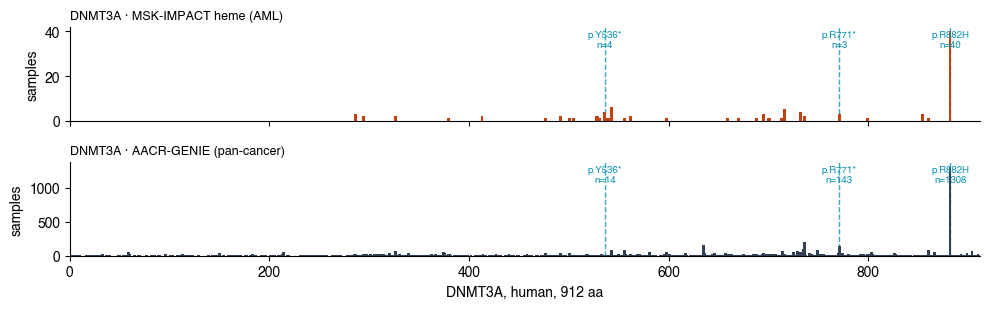

,HGVSp_Short,aa_pos,heme_samples,GENIE_samples
0,p.R882H,882,40,1308
1,p.Y536*,536,4,14
2,p.R771*,771,3,143


In [149]:
# One plot per gene: where the mutations fall on the protein, in both cohorts,
# with the selected residues marked. The SELECTION is made on heme (these are
# AML/CH designs); GENIE is shown only as a check that a pick recurs outside
# this one cohort.
import matplotlib.pyplot as plt
import re

# Protein lengths of the canonical transcripts PEGG designs against (GENCODE
# v19 / GRCh37). Taken from the annotation rather than typed from memory, so the
# x-axis matches the transcript the pegRNAs are actually built for.
PROTEIN_AA = {
    'DNMT3A': 912, 'TET2': 2002, 'ASXL1': 1541, 'IDH1': 414, 'IDH2': 452,
    'SF3B1': 1304, 'SRSF2': 221, 'U2AF1': 240, 'JAK2': 1132, 'TP53': 393,
    'PPM1D': 605, 'FLT3': 993, 'NRAS': 189, 'KRAS': 189, 'KIT': 976,
    'PTPN11': 593, 'NPM1': 294, 'RUNX1': 480, 'WT1': 517,
}


def aa_position(hgvsp):
    """First residue number in an HGVSp_Short string, or None.

    Handles 'p.R882H', 'p.R771*', 'p.Q527fs' and the frameshift/indel forms; the
    number is all that matters here, not what the change is.
    """
    if not isinstance(hgvsp, str):
        return None
    found = re.search(r'(\d+)', hgvsp)
    return int(found.group(1)) if found else None


def _counts(df, gene, classifications=None):
    """Per-residue mutation counts, counted once per sample."""
    sub = df[df['Hugo_Symbol'] == gene].copy()
    if classifications is not None:
        sub = sub[sub['Variant_Classification'].isin(classifications)]
    sub['aa_pos'] = sub['HGVSp_Short'].map(aa_position)
    sub = sub[sub['aa_pos'].notna() & sub['aa_pos'].between(1, PROTEIN_AA[gene])]
    #one row per sample per change, so a sample sequenced twice is not counted twice
    if 'Tumor_Sample_Barcode' in sub.columns:
        sub = sub.drop_duplicates(subset=['Tumor_Sample_Barcode', 'HGVSp_Short'])
    return sub.groupby('aa_pos').size()


def plot_gene(gene, selected_df, classifications=None, note=None):
    """Draws the heme and GENIE mutation profiles for one gene.

    selected_df is the *_SELECTED table for that gene; its residues are marked in
    both panels. classifications restricts the plot to certain variant types
    (e.g. ['Missense_Mutation'] for FLT3-TKD), matching how the variants were
    picked. Returns a table of the picks with their count in each cohort.
    """
    length = PROTEIN_AA[gene]
    heme_counts = _counts(df_mutation_heme, gene, classifications)
    genie_counts = _counts(df_mutation_genie, gene, classifications)

    selected = (selected_df['HGVSp_Short'].map(aa_position)
                .dropna().astype(int).tolist())
    labels = dict(zip(selected, selected_df['HGVSp_Short']))

    fig, axes = plt.subplots(2, 1, figsize=(10, 3.2), sharex=True)
    title = gene + (' — %s' % note if note else '')
    for ax, (counts, name, colour) in zip(
            axes, [(heme_counts, '%s · MSK-IMPACT heme (AML)' % title, '#c2410c'),
                   (genie_counts, '%s · AACR-GENIE (pan-cancer)' % title, '#334155')]):
        if len(counts):
            ax.bar(counts.index, counts.values,
                   width=max(1.5, length / 320), color=colour, linewidth=0)
        ax.set_ylabel('samples')
        ax.set_title(name, loc='left', fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)

        #mark the picks in BOTH panels, so a site common in one cohort and absent
        #from the other is visible rather than assumed
        for pos in selected:
            ax.axvline(pos, color='#0891b2', lw=1, ls='--', alpha=0.8, zorder=0)
            ax.annotate('%s\nn=%d' % (labels[pos], int(counts.get(pos, 0))),
                        xy=(pos, ax.get_ylim()[1]), xytext=(0, -2),
                        textcoords='offset points', ha='center', va='top',
                        fontsize=7, color='#0891b2')

    axes[1].set_xlabel('%s, human, %d aa' % (gene, length))
    axes[1].set_xlim(0, length)
    fig.tight_layout()
    plt.show()

    return pd.DataFrame({
        'HGVSp_Short': [labels[p] for p in selected],
        'aa_pos': selected,
        'heme_samples': [int(heme_counts.get(p, 0)) for p in selected],
        'GENIE_samples': [int(genie_counts.get(p, 0)) for p in selected],
    }).sort_values('heme_samples', ascending=False).reset_index(drop=True)


plot_gene('DNMT3A', DNMT3A_SELECTED)

## TET2

In [288]:
# TET2
TET2 = df_mutation[df_mutation['Hugo_Symbol'] == 'TET2'].reset_index(drop=True)
TET2_LOF = filter_variants(TET2, classifications=LOF_CLASSES)
TET2_MIS = filter_variants(TET2, classifications=['Missense_Mutation'])

In [289]:
TET2_LOF

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,TET2,54790.0,NaN,GRCh37,4,106156442,106156442,+,frameshift_variant,Frame_Shift_Del,...,p.V449*,ENST00000380013,NM_001127208.2,448.0,gAa/ga,3/11,SUCCESS,NaN,557,4
1,TET2,54790.0,NaN,GRCh37,4,106156351,106156354,+,frameshift_variant,Frame_Shift_Del,...,p.P419Qfs*7,ENST00000380013,NM_001127208.2,418.0,CTTCct/ct,3/11,SUCCESS,NaN,542,4
2,TET2,54790.0,NaN,GRCh37,4,106193931,106193931,+,stop_gained,Nonsense_Mutation,...,p.R1465*,ENST00000380013,NM_001127208.2,1465.0,Cga/Tga,10/11,SUCCESS,NaN,380,3
3,TET2,54790.0,NaN,GRCh37,4,106193995,106193995,+,stop_gained,Nonsense_Mutation,...,p.S1486*,ENST00000380013,NM_001127208.2,1486.0,tCa/tGa,10/11,SUCCESS,NaN,845,2
4,TET2,54790.0,NaN,GRCh37,4,106157583,106157583,+,stop_gained,Nonsense_Mutation,...,p.C828*,ENST00000380013,NM_001127208.2,828.0,tgC/tgA,3/11,SUCCESS,NaN,903,2
5,TET2,54790.0,NaN,GRCh37,4,106156043,106156043,+,frameshift_variant,Frame_Shift_Del,...,p.Q317Rfs*30,ENST00000380013,NM_001127208.2,315.0,tCc/tc,3/11,SUCCESS,NaN,662,2
6,TET2,54790.0,NaN,GRCh37,4,106196332,106196335,+,frameshift_variant,Frame_Shift_Del,...,p.V1557Tfs*13,ENST00000380013,NM_001127208.2,1555.0,gaGTCT/ga,11/11,SUCCESS,NaN,495,2
7,TET2,54790.0,NaN,GRCh37,4,106155829,106155829,+,frameshift_variant,Frame_Shift_Del,...,p.T245Pfs*5,ENST00000380013,NM_001127208.2,244.0,Aaa/aa,3/11,SUCCESS,NaN,1182,2
8,TET2,54790.0,NaN,GRCh37,4,106157054,106157054,+,frameshift_variant,Frame_Shift_Del,...,p.Q652Rfs*48,ENST00000380013,NM_001127208.2,652.0,cAg/cg,3/11,SUCCESS,NaN,982,1
9,TET2,54790.0,NaN,GRCh37,4,106156134,106156135,+,frameshift_variant,Frame_Shift_Ins,...,p.S348*,ENST00000380013,NM_001127208.2,345.0,-/CTAGC,3/11,SUCCESS,NaN,648,1


In [290]:
TET2_LOF_SELECTED = TET2_LOF[TET2_LOF['HGVSp_Short'].isin(['p.Q652Rfs*48', 'p.S1486*'])].reset_index(drop=True)
TET2_LOF_SELECTED

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,TET2,54790.0,NaN,GRCh37,4,106193995,106193995,+,stop_gained,Nonsense_Mutation,...,p.S1486*,ENST00000380013,NM_001127208.2,1486.0,tCa/tGa,10/11,SUCCESS,NaN,845,2
1,TET2,54790.0,NaN,GRCh37,4,106157054,106157054,+,frameshift_variant,Frame_Shift_Del,...,p.Q652Rfs*48,ENST00000380013,NM_001127208.2,652.0,cAg/cg,3/11,SUCCESS,NaN,982,1


In [291]:
#pd.concat rather than DataFrame.append, which pandas 2.0 removed
TET2_SELECTED = TET2_LOF_SELECTED
TET2_SELECTED

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,TET2,54790.0,NaN,GRCh37,4,106193995,106193995,+,stop_gained,Nonsense_Mutation,...,p.S1486*,ENST00000380013,NM_001127208.2,1486.0,tCa/tGa,10/11,SUCCESS,NaN,845,2
1,TET2,54790.0,NaN,GRCh37,4,106157054,106157054,+,frameshift_variant,Frame_Shift_Del,...,p.Q652Rfs*48,ENST00000380013,NM_001127208.2,652.0,cAg/cg,3/11,SUCCESS,NaN,982,1


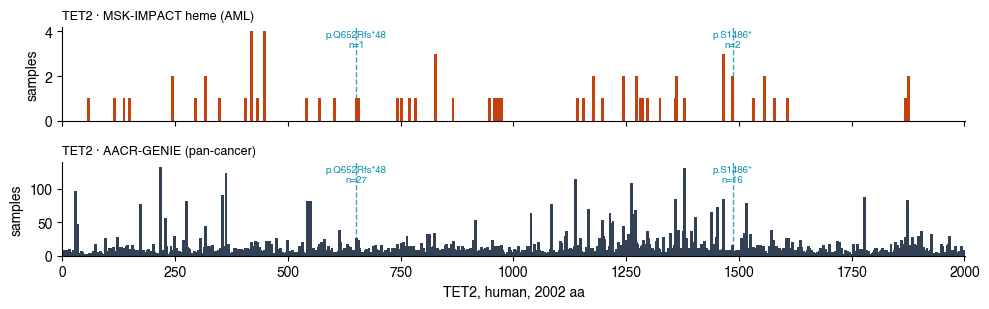

,HGVSp_Short,aa_pos,heme_samples,GENIE_samples
0,p.S1486*,1486,2,16
1,p.Q652Rfs*48,652,1,27


In [292]:
# TET2 plot
plot_gene('TET2', TET2_SELECTED)

## ASXL1

In [271]:
# ASXL1
ASXL1 = df_mutation[df_mutation['Hugo_Symbol'] == 'ASXL1'].reset_index(drop=True)
ASXL1_LOF = filter_variants(ASXL1, classifications=LOF_CLASSES)

In [272]:
ASXL1_LOF

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,ASXL1,171023.0,NaN,GRCh37,20,31022441,31022442,+,frameshift_variant,Frame_Shift_Ins,...,p.G646Wfs*12,ENST00000375687,NM_015338.5,642.0,-/G,13/13,SUCCESS,NaN,265,8
1,ASXL1,171023.0,NaN,GRCh37,20,31022403,31022425,+,frameshift_variant,Frame_Shift_Del,...,p.E635Rfs*15,ENST00000375687,NM_015338.5,630.0,CACCACTGCCATAGAGAGGCGGCc/c,13/13,SUCCESS,NaN,343,5
2,ASXL1,171023.0,NaN,GRCh37,20,31022548,31022548,+,frameshift_variant,Frame_Shift_Del,...,p.G679Efs*24,ENST00000375687,NM_015338.5,678.0,aGg/ag,13/13,SUCCESS,NaN,492,3
3,ASXL1,171023.0,NaN,GRCh37,20,31022982,31022982,+,frameshift_variant,Frame_Shift_Del,...,p.L823*,ENST00000375687,NM_015338.5,823.0,Tta/ta,13/13,SUCCESS,NaN,717,2
4,ASXL1,171023.0,NaN,GRCh37,20,31022592,31022592,+,stop_gained,Nonsense_Mutation,...,p.R693*,ENST00000375687,NM_015338.5,693.0,Cga/Tga,13/13,SUCCESS,NaN,836,2
5,ASXL1,171023.0,NaN,GRCh37,20,31021295,31021295,+,stop_gained,Nonsense_Mutation,...,p.Q432*,ENST00000375687,NM_015338.5,432.0,Caa/Taa,12/13,SUCCESS,NaN,581,2
6,ASXL1,171023.0,NaN,GRCh37,20,31023144,31023144,+,stop_gained,Nonsense_Mutation,...,p.E877*,ENST00000375687,NM_015338.5,877.0,Gaa/Taa,13/13,SUCCESS,NaN,700,2
7,ASXL1,171023.0,NaN,GRCh37,20,31022937,31022937,+,frameshift_variant,Frame_Shift_Del,...,p.P808Lfs*10,ENST00000375687,NM_015338.5,808.0,Cct/ct,13/13,SUCCESS,NaN,972,2
8,ASXL1,171023.0,NaN,GRCh37,20,31022853,31022853,+,stop_gained,Nonsense_Mutation,...,p.Q780*,ENST00000375687,NM_015338.5,780.0,Cag/Tag,13/13,SUCCESS,NaN,854,2
9,ASXL1,171023.0,NaN,GRCh37,20,31022767,31022768,+,frameshift_variant,Frame_Shift_Del,...,p.V751Gfs*22,ENST00000375687,NM_015338.5,751.0,gTT/g,13/13,SUCCESS,NaN,900,1


In [273]:
ASXL1_LOF_SELECTED = ASXL1_LOF[ASXL1_LOF['HGVSp_Short'].isin(['p.G646Wfs*12', 'p.G679Efs*24','p.R693*'])].reset_index(drop=True)
ASXL1_LOF_SELECTED

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,ASXL1,171023.0,NaN,GRCh37,20,31022441,31022442,+,frameshift_variant,Frame_Shift_Ins,...,p.G646Wfs*12,ENST00000375687,NM_015338.5,642.0,-/G,13/13,SUCCESS,NaN,265,8
1,ASXL1,171023.0,NaN,GRCh37,20,31022548,31022548,+,frameshift_variant,Frame_Shift_Del,...,p.G679Efs*24,ENST00000375687,NM_015338.5,678.0,aGg/ag,13/13,SUCCESS,NaN,492,3
2,ASXL1,171023.0,NaN,GRCh37,20,31022592,31022592,+,stop_gained,Nonsense_Mutation,...,p.R693*,ENST00000375687,NM_015338.5,693.0,Cga/Tga,13/13,SUCCESS,NaN,836,2


In [274]:
#pd.concat rather than DataFrame.append, which pandas 2.0 removed
ASXL1_SELECTED = ASXL1_LOF_SELECTED
ASXL1_SELECTED

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,ASXL1,171023.0,NaN,GRCh37,20,31022441,31022442,+,frameshift_variant,Frame_Shift_Ins,...,p.G646Wfs*12,ENST00000375687,NM_015338.5,642.0,-/G,13/13,SUCCESS,NaN,265,8
1,ASXL1,171023.0,NaN,GRCh37,20,31022548,31022548,+,frameshift_variant,Frame_Shift_Del,...,p.G679Efs*24,ENST00000375687,NM_015338.5,678.0,aGg/ag,13/13,SUCCESS,NaN,492,3
2,ASXL1,171023.0,NaN,GRCh37,20,31022592,31022592,+,stop_gained,Nonsense_Mutation,...,p.R693*,ENST00000375687,NM_015338.5,693.0,Cga/Tga,13/13,SUCCESS,NaN,836,2


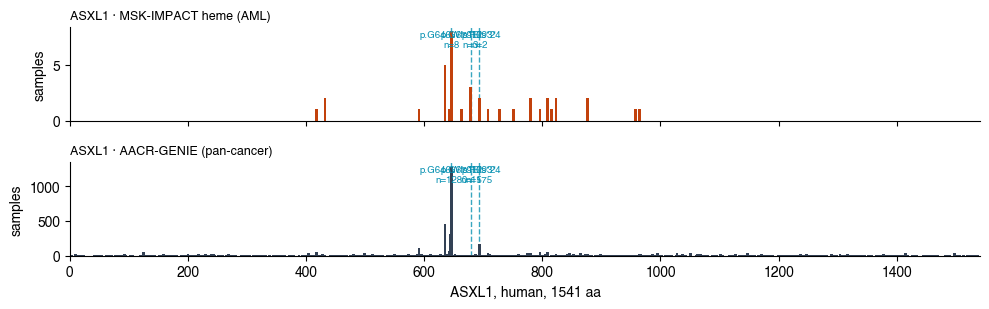

,HGVSp_Short,aa_pos,heme_samples,GENIE_samples
0,p.G646Wfs*12,646,8,1280
1,p.G679Efs*24,679,3,15
2,p.R693*,693,2,175


In [275]:
# AXSL1 plot
plot_gene('ASXL1', ASXL1_SELECTED)

## IDH1

In [160]:
# IDH1
IDH1 = df_mutation[df_mutation['Hugo_Symbol'] == 'IDH1'].reset_index(drop=True)
IDH1_MIS = filter_variants(IDH1, classifications=['Missense_Mutation'])
IDH1_MIS

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,IDH1,3417.0,NaN,GRCh37,2,209113113,209113113,+,missense_variant,Missense_Mutation,...,p.R132C,ENST00000345146,NM_005896.2,132.0,Cgt/Tgt,4/10,SUCCESS,NaN,669,17
1,IDH1,3417.0,NaN,GRCh37,2,209113112,209113112,+,missense_variant,Missense_Mutation,...,p.R132H,ENST00000345146,NM_005896.2,132.0,cGt/cAt,4/10,SUCCESS,NaN,590,4
2,IDH1,3417.0,NaN,GRCh37,2,209113113,209113113,+,missense_variant,Missense_Mutation,...,p.R132S,ENST00000345146,NM_005896.2,132.0,Cgt/Agt,4/10,SUCCESS,NaN,568,2
3,IDH1,3417.0,NaN,GRCh37,2,209113112,209113112,+,missense_variant,Missense_Mutation,...,p.R132L,ENST00000345146,NM_005896.2,132.0,cGt/cTt,4/10,SUCCESS,NaN,422,2
4,IDH1,3417.0,NaN,GRCh37,2,209113113,209113113,+,missense_variant,Missense_Mutation,...,p.R132G,ENST00000345146,NM_005896.2,132.0,Cgt/Ggt,4/10,SUCCESS,NaN,564,1


In [161]:
IDH1_SELECTED = IDH1_MIS[IDH1_MIS['HGVSp_Short'].isin(['p.R132H'])].reset_index(drop=True)
IDH1_SELECTED

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,IDH1,3417.0,NaN,GRCh37,2,209113112,209113112,+,missense_variant,Missense_Mutation,...,p.R132H,ENST00000345146,NM_005896.2,132.0,cGt/cAt,4/10,SUCCESS,NaN,590,4


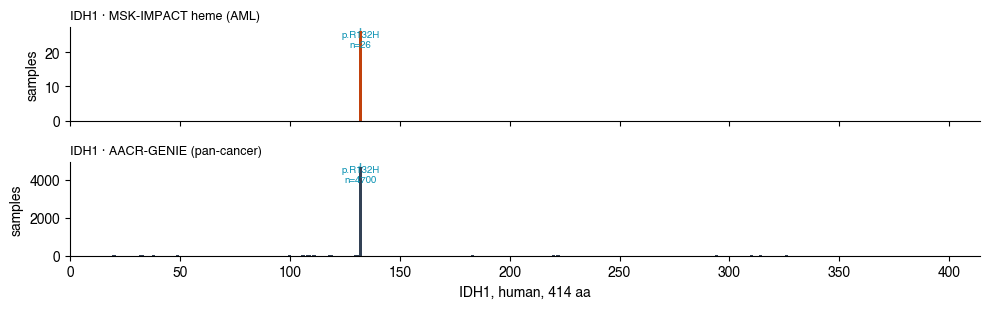

,HGVSp_Short,aa_pos,heme_samples,GENIE_samples
0,p.R132H,132,26,4700


In [162]:
# IDH1 plot
plot_gene('IDH1', IDH1_SELECTED, classifications=['Missense_Mutation'])

## IDH2

In [163]:
# IDH2
IDH2 = df_mutation[df_mutation['Hugo_Symbol'] == 'IDH2'].reset_index(drop=True)
IDH2_MIS = filter_variants(IDH2, classifications=['Missense_Mutation'])
IDH2_MIS

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,IDH2,3418.0,NaN,GRCh37,15,90631934,90631934,+,missense_variant,Missense_Mutation,...,p.R140Q,ENST00000330062,NM_002168.2,140.0,cGg/cAg,4/11,SUCCESS,NaN,641,22
1,IDH2,3418.0,NaN,GRCh37,15,90631838,90631838,+,missense_variant,Missense_Mutation,...,p.R172K,ENST00000330062,NM_002168.2,172.0,aGg/aAg,4/11,SUCCESS,NaN,514,10
2,IDH2,3418.0,NaN,GRCh37,15,90633834,90633834,+,missense_variant,Missense_Mutation,...,p.L84F,ENST00000330062,NM_002168.2,84.0,Ctc/Ttc,3/11,SUCCESS,NaN,813,1


In [164]:
IDH2_SELECTED = IDH2_MIS[IDH2_MIS['HGVSp_Short'].isin(['p.R140Q'])].reset_index(drop=True)
IDH2_SELECTED

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,IDH2,3418.0,NaN,GRCh37,15,90631934,90631934,+,missense_variant,Missense_Mutation,...,p.R140Q,ENST00000330062,NM_002168.2,140.0,cGg/cAg,4/11,SUCCESS,NaN,641,22


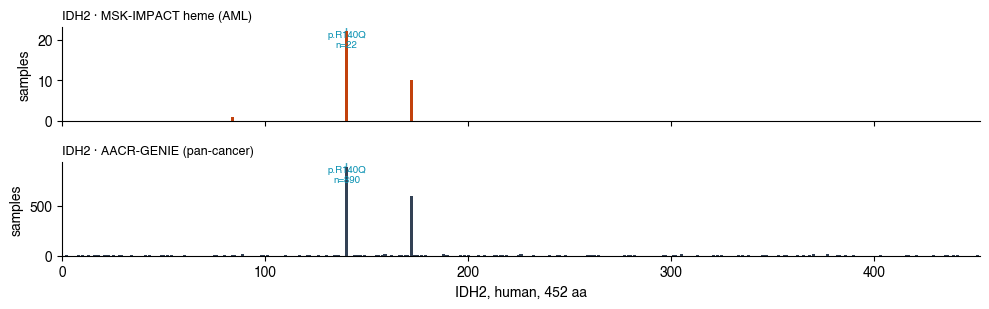

,HGVSp_Short,aa_pos,heme_samples,GENIE_samples
0,p.R140Q,140,22,890


In [165]:
# IDH2 plot
plot_gene('IDH2', IDH2_SELECTED, classifications=['Missense_Mutation'])

## SF3B1

In [166]:
# SF3B1
SF3B1 = df_mutation[df_mutation['Hugo_Symbol'] == 'SF3B1'].reset_index(drop=True)
SF3B1 = filter_variants(SF3B1)
SF3B1

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,SF3B1,23451.0,NaN,GRCh37,2,198266834,198266834,+,missense_variant,Missense_Mutation,...,p.K700E,ENST00000335508,NM_012433.2,700.0,Aaa/Gaa,15/25,SUCCESS,NaN,809,5
1,SF3B1,23451.0,NaN,GRCh37,2,198267360,198267360,+,missense_variant,Missense_Mutation,...,p.K666M,ENST00000335508,NM_012433.2,666.0,aAg/aTg,14/25,SUCCESS,NaN,940,2
2,SF3B1,23451.0,NaN,GRCh37,2,198267359,198267359,+,missense_variant,Missense_Mutation,...,p.K666N,ENST00000335508,NM_012433.2,666.0,aaG/aaT,14/25,SUCCESS,NaN,1331,2
3,SF3B1,23451.0,NaN,GRCh37,2,198266810,198266810,+,missense_variant,Missense_Mutation,...,p.A708P,ENST00000335508,NM_012433.2,708.0,Gcc/Ccc,15/25,SUCCESS,NaN,409,1
4,SF3B1,23451.0,NaN,GRCh37,2,198267484,198267484,+,missense_variant,Missense_Mutation,...,p.R625C,ENST00000335508,NM_012433.2,625.0,Cgt/Tgt,14/25,SUCCESS,NaN,1172,1
5,SF3B1,23451.0,NaN,GRCh37,2,198267705,198267705,+,missense_variant,Missense_Mutation,...,p.E592K,ENST00000335508,NM_012433.2,592.0,Gaa/Aaa,13/25,SUCCESS,NaN,671,1
6,SF3B1,23451.0,NaN,GRCh37,2,198266605,198266605,+,missense_variant,Missense_Mutation,...,p.A744D,ENST00000335508,NM_012433.2,744.0,gCt/gAt,16/25,SUCCESS,NaN,644,1
7,SF3B1,23451.0,NaN,GRCh37,2,198267359,198267359,+,missense_variant,Missense_Mutation,...,p.K666N,ENST00000335508,NM_012433.2,666.0,aaG/aaC,14/25,SUCCESS,NaN,950,1


In [167]:
SF3B1_SELECTED = SF3B1[SF3B1['HGVSp_Short'].isin(['p.K700E'])].reset_index(drop=True)
SF3B1_SELECTED

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,SF3B1,23451.0,NaN,GRCh37,2,198266834,198266834,+,missense_variant,Missense_Mutation,...,p.K700E,ENST00000335508,NM_012433.2,700.0,Aaa/Gaa,15/25,SUCCESS,NaN,809,5


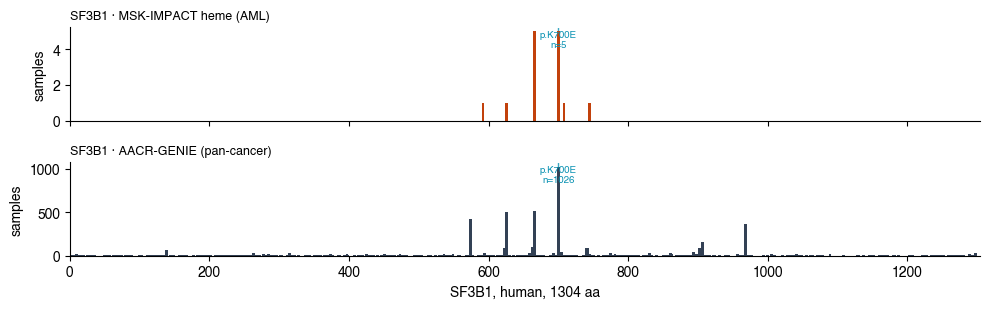

,HGVSp_Short,aa_pos,heme_samples,GENIE_samples
0,p.K700E,700,5,1026


In [168]:
# SF3B1 plot
plot_gene('SF3B1', SF3B1_SELECTED)

## SRSF2

In [169]:
# SRSF2
SRSF2 = df_mutation[df_mutation['Hugo_Symbol'] == 'SRSF2'].reset_index(drop=True)
SRSF2 = filter_variants(SRSF2)
SRSF2

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,SRSF2,6427.0,NaN,GRCh37,17,74732959,74732959,+,missense_variant,Missense_Mutation,...,p.P95H,ENST00000359995,NM_001195427.1,95.0,cCc/cAc,1/3,SUCCESS,NaN,334,24
1,SRSF2,6427.0,NaN,GRCh37,17,74732959,74732959,+,missense_variant,Missense_Mutation,...,p.P95L,ENST00000359995,NM_001195427.1,95.0,cCc/cTc,1/3,SUCCESS,NaN,380,18
2,SRSF2,6427.0,NaN,GRCh37,17,74732959,74732959,+,missense_variant,Missense_Mutation,...,p.P95R,ENST00000359995,NM_001195427.1,95.0,cCc/cGc,1/3,SUCCESS,NaN,574,3
3,SRSF2,6427.0,NaN,GRCh37,17,74732936,74732959,+,inframe_deletion,In_Frame_Del,...,p.P95_R102del,ENST00000359995,NM_001195427.1,95.0,cCCCCGGACTCACACCACAGCCGCCgg/cgg,1/3,SUCCESS,NaN,322,3


In [170]:
SRSF2_SELECTED = SRSF2[SRSF2['HGVSp_Short'].isin(['p.P95H'])].reset_index(drop=True)
SRSF2_SELECTED

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,SRSF2,6427.0,NaN,GRCh37,17,74732959,74732959,+,missense_variant,Missense_Mutation,...,p.P95H,ENST00000359995,NM_001195427.1,95.0,cCc/cAc,1/3,SUCCESS,NaN,334,24


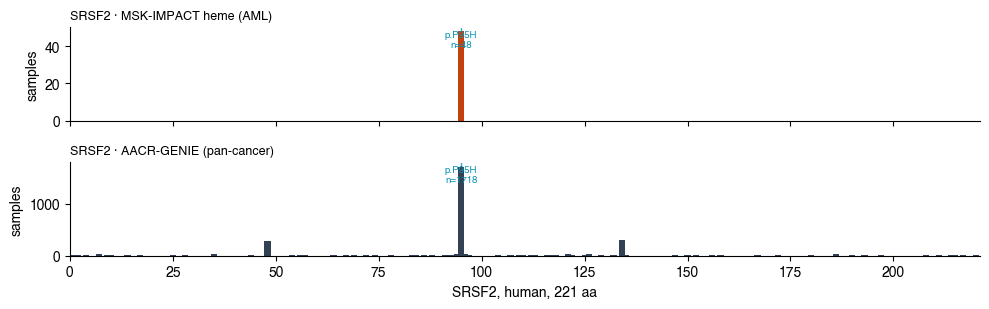

,HGVSp_Short,aa_pos,heme_samples,GENIE_samples
0,p.P95H,95,48,1718


In [171]:
# SRSF2 plot
plot_gene('SRSF2', SRSF2_SELECTED)

## U2AF1

In [172]:
# U2AF1
U2AF1 = df_mutation[df_mutation['Hugo_Symbol'] == 'U2AF1'].reset_index(drop=True)
U2AF1 = filter_variants(U2AF1)
U2AF1

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,U2AF1,7307.0,NaN,GRCh37,21,44524456,44524456,+,missense_variant,Missense_Mutation,...,p.S34F,ENST00000291552,NM_006758.2,34.0,tCt/tTt,2/8,SUCCESS,NaN,923,14
1,U2AF1,7307.0,NaN,GRCh37,21,44514777,44514777,+,missense_variant,Missense_Mutation,...,p.Q157R,ENST00000291552,NM_006758.2,157.0,cAg/cGg,6/8,SUCCESS,NaN,868,5
2,U2AF1,7307.0,NaN,GRCh37,21,44514777,44514777,+,missense_variant,Missense_Mutation,...,p.Q157P,ENST00000291552,NM_006758.2,157.0,cAg/cCg,6/8,SUCCESS,NaN,522,2
3,U2AF1,7307.0,NaN,GRCh37,21,44524456,44524456,+,missense_variant,Missense_Mutation,...,p.S34C,ENST00000291552,NM_006758.2,34.0,tCt/tGt,2/8,SUCCESS,NaN,567,2


In [173]:
U2AF1_SELECTED = U2AF1[U2AF1['HGVSp_Short'].isin(['p.S34F'])].reset_index(drop=True)
U2AF1_SELECTED

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,U2AF1,7307.0,NaN,GRCh37,21,44524456,44524456,+,missense_variant,Missense_Mutation,...,p.S34F,ENST00000291552,NM_006758.2,34.0,tCt/tTt,2/8,SUCCESS,NaN,923,14


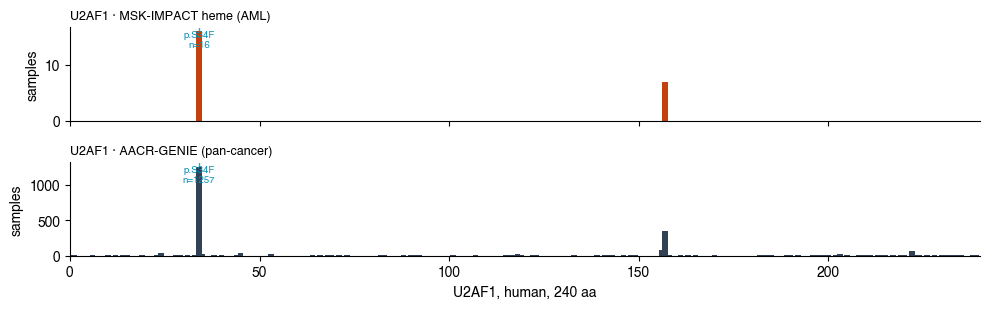

,HGVSp_Short,aa_pos,heme_samples,GENIE_samples
0,p.S34F,34,16,1257


In [174]:
# U2AF1 plot
plot_gene('U2AF1', U2AF1_SELECTED)

## JAK2

In [175]:
# JAK2
JAK2 = df_mutation[df_mutation['Hugo_Symbol'] == 'JAK2'].reset_index(drop=True)
JAK2 = filter_variants(JAK2)
JAK2

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,JAK2,3717.0,NaN,GRCh37,9,5073770,5073770,+,missense_variant,Missense_Mutation,...,p.V617F,ENST00000381652,NM_004972.3,617.0,Gtc/Ttc,14/25,SUCCESS,NaN,766,7


In [176]:
JAK2_SELECTED = JAK2[JAK2['HGVSp_Short'].isin(['p.V617F'])].reset_index(drop=True)
JAK2_SELECTED

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,JAK2,3717.0,NaN,GRCh37,9,5073770,5073770,+,missense_variant,Missense_Mutation,...,p.V617F,ENST00000381652,NM_004972.3,617.0,Gtc/Ttc,14/25,SUCCESS,NaN,766,7


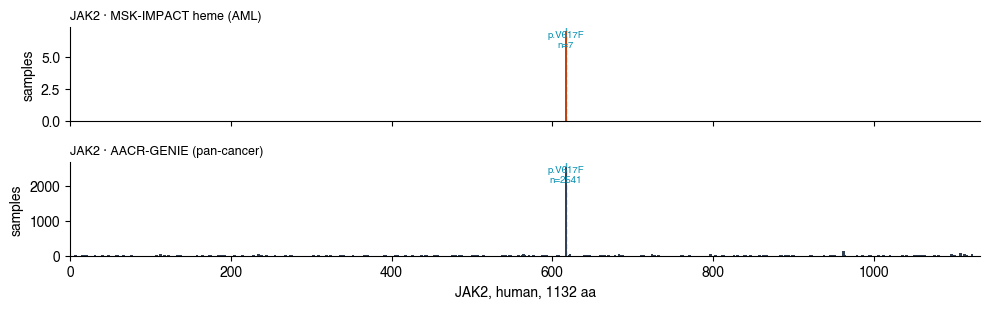

,HGVSp_Short,aa_pos,heme_samples,GENIE_samples
0,p.V617F,617,7,2541


In [177]:
# JAK2 plot
plot_gene('JAK2', JAK2_SELECTED)

## TP53

In [178]:
# TP53
TP53 = df_mutation[df_mutation['Hugo_Symbol'] == 'TP53'].reset_index(drop=True)
TP53 = filter_variants(TP53)
TP53

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,TP53,7157.0,NaN,GRCh37,17,7577094,7577094,+,missense_variant,Missense_Mutation,...,p.R282W,ENST00000269305,NM_001126112.2,282.0,Cgg/Tgg,8/11,SUCCESS,NaN,846,7
1,TP53,7157.0,NaN,GRCh37,17,7577120,7577120,+,missense_variant,Missense_Mutation,...,p.R273H,ENST00000269305,NM_001126112.2,273.0,cGt/cAt,8/11,SUCCESS,NaN,714,7
2,TP53,7157.0,NaN,GRCh37,17,7578268,7578268,+,missense_variant,Missense_Mutation,...,p.L194R,ENST00000269305,NM_001126112.2,194.0,cTt/cGt,6/11,SUCCESS,NaN,498,5
3,TP53,7157.0,NaN,GRCh37,17,7578190,7578190,+,missense_variant,Missense_Mutation,...,p.Y220C,ENST00000269305,NM_001126112.2,220.0,tAt/tGt,6/11,SUCCESS,NaN,343,5
4,TP53,7157.0,NaN,GRCh37,17,7578442,7578442,+,missense_variant,Missense_Mutation,...,p.Y163C,ENST00000269305,NM_001126112.2,163.0,tAc/tGc,5/11,SUCCESS,NaN,622,5
5,TP53,7157.0,NaN,GRCh37,17,7578263,7578263,+,stop_gained,Nonsense_Mutation,...,p.R196*,ENST00000269305,NM_001126112.2,196.0,Cga/Tga,6/11,SUCCESS,NaN,472,5
6,TP53,7157.0,NaN,GRCh37,17,7577121,7577121,+,missense_variant,Missense_Mutation,...,p.R273C,ENST00000269305,NM_001126112.2,273.0,Cgt/Tgt,8/11,SUCCESS,NaN,1007,4
7,TP53,7157.0,NaN,GRCh37,17,7573987,7573987,+,missense_variant,Missense_Mutation,...,p.A347D,ENST00000269305,NM_001126112.2,347.0,gCc/gAc,10/11,SUCCESS,NaN,862,4
8,TP53,7157.0,NaN,GRCh37,17,7578406,7578406,+,missense_variant,Missense_Mutation,...,p.R175H,ENST00000269305,NM_001126112.2,175.0,cGc/cAc,5/11,SUCCESS,NaN,736,3
9,TP53,7157.0,NaN,GRCh37,17,7577539,7577539,+,missense_variant,Missense_Mutation,...,p.R248W,ENST00000269305,NM_001126112.2,248.0,Cgg/Tgg,7/11,SUCCESS,NaN,1316,3


In [179]:
TP53_SELECTED = TP53[TP53['HGVSp_Short'].isin(['p.R175H','p.R273H','p.R248W'])].reset_index(drop=True)
TP53_SELECTED

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,TP53,7157.0,NaN,GRCh37,17,7577120,7577120,+,missense_variant,Missense_Mutation,...,p.R273H,ENST00000269305,NM_001126112.2,273.0,cGt/cAt,8/11,SUCCESS,NaN,714,7
1,TP53,7157.0,NaN,GRCh37,17,7578406,7578406,+,missense_variant,Missense_Mutation,...,p.R175H,ENST00000269305,NM_001126112.2,175.0,cGc/cAc,5/11,SUCCESS,NaN,736,3
2,TP53,7157.0,NaN,GRCh37,17,7577539,7577539,+,missense_variant,Missense_Mutation,...,p.R248W,ENST00000269305,NM_001126112.2,248.0,Cgg/Tgg,7/11,SUCCESS,NaN,1316,3


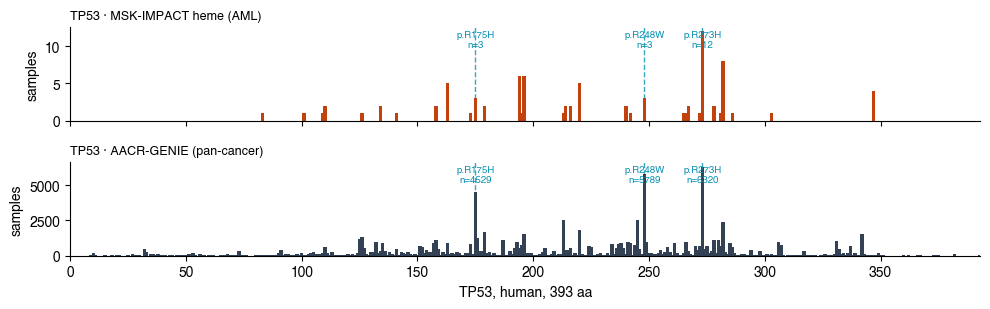

,HGVSp_Short,aa_pos,heme_samples,GENIE_samples
0,p.R273H,273,12,6320
1,p.R175H,175,3,4529
2,p.R248W,248,3,5789


In [180]:
# TP53 plot
plot_gene('TP53', TP53_SELECTED)

## PPM1D

In [181]:
# PPM1D
PPM1D = df_mutation_genie[df_mutation_genie['Hugo_Symbol'] == 'PPM1D'].reset_index(drop=True)
PPM1D = filter_variants(PPM1D)
PPM1D

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,Polyphen_Prediction,Polyphen_Score,SIFT_Prediction,SIFT_Score,SWISSPROT,n_depth,t_depth,Annotation_Status,mutationInCis_Flag,count
0,PPM1D,8493.0,DFCI,GRCh37,17,58740439,58740439,+,frameshift_variant,Frame_Shift_Del,...,NaN,NaN,NaN,NaN,NaN,NaN,423.0,SUCCESS,False,137
1,PPM1D,8493.0,DFCI,GRCh37,17,58740624,58740624,+,frameshift_variant,Frame_Shift_Del,...,NaN,NaN,NaN,NaN,NaN,NaN,543.0,SUCCESS,False,137
2,PPM1D,8493.0,DFCI,GRCh37,17,58740623,58740624,+,frameshift_variant,Frame_Shift_Ins,...,NaN,NaN,NaN,NaN,NaN,NaN,241.0,SUCCESS,False,48
3,PPM1D,8493.0,DFCI,GRCh37,17,58740668,58740668,+,stop_gained,Nonsense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,346.0,SUCCESS,False,45
4,PPM1D,8493.0,DFCI,GRCh37,17,58740467,58740467,+,stop_gained,Nonsense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,281.0,SUCCESS,False,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
980,PPM1D,8493.0,MSK,GRCh37,17,58740486,58740488,+,frameshift_variant,Frame_Shift_Del,...,NaN,NaN,NaN,NaN,NaN,590.0,586.0,SUCCESS,False,1
981,PPM1D,8493.0,MSK,GRCh37,17,58711223,58711223,+,missense_variant,Missense_Mutation,...,benign,0.388,tolerated,0.70,NaN,122.0,889.0,SUCCESS,False,1
982,PPM1D,8493.0,MSK,GRCh37,17,58740636,58740637,+,frameshift_variant,Frame_Shift_Del,...,NaN,NaN,NaN,NaN,NaN,422.0,641.0,SUCCESS,False,1
983,PPM1D,8493.0,MSK,GRCh37,17,58740632,58740632,+,missense_variant,Missense_Mutation,...,benign,0.131,deleterious_low_confidence,0.05,NaN,610.0,781.0,SUCCESS,False,1


In [182]:
PPM1D_SELECTED = PPM1D[PPM1D['HGVSp_Short'].isin(['p.R458*','p.N512Ifs*2'])].reset_index(drop=True)
PPM1D_SELECTED

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,Polyphen_Prediction,Polyphen_Score,SIFT_Prediction,SIFT_Score,SWISSPROT,n_depth,t_depth,Annotation_Status,mutationInCis_Flag,count
0,PPM1D,8493.0,DFCI,GRCh37,17,58740624,58740624,+,frameshift_variant,Frame_Shift_Del,...,NaN,NaN,NaN,NaN,NaN,NaN,543.0,SUCCESS,False,137
1,PPM1D,8493.0,DFCI,GRCh37,17,58740467,58740467,+,stop_gained,Nonsense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,281.0,SUCCESS,False,36


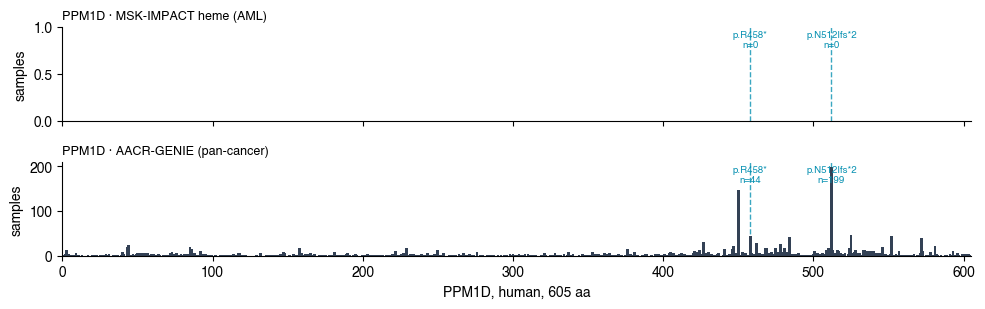

,HGVSp_Short,aa_pos,heme_samples,GENIE_samples
0,p.N512Ifs*2,512,0,199
1,p.R458*,458,0,44


In [183]:
# PPM1D plot
plot_gene('PPM1D', PPM1D_SELECTED)

# AML mutations

## FLT3-TKD

In [184]:
# FLT3-TKD
FLT3_TKD = df_mutation[df_mutation['Hugo_Symbol'] == 'FLT3'].reset_index(drop=True)
FLT3_TKD = filter_variants(FLT3_TKD, classifications=['Missense_Mutation'])
FLT3_TKD

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,FLT3,2322.0,NaN,GRCh37,13,28592642,28592642,+,missense_variant,Missense_Mutation,...,p.D835Y,ENST00000241453,NM_004119.2,835.0,Gat/Tat,20/24,SUCCESS,NaN,763,7
1,FLT3,2322.0,NaN,GRCh37,13,28592641,28592641,+,missense_variant,Missense_Mutation,...,p.D835V,ENST00000241453,NM_004119.2,835.0,gAt/gTt,20/24,SUCCESS,NaN,764,4
2,FLT3,2322.0,NaN,GRCh37,13,28592642,28592642,+,missense_variant,Missense_Mutation,...,p.D835H,ENST00000241453,NM_004119.2,835.0,Gat/Cat,20/24,SUCCESS,NaN,619,2
3,FLT3,2322.0,NaN,GRCh37,13,28601361,28601361,+,missense_variant,Missense_Mutation,...,p.F691L,ENST00000241453,NM_004119.2,691.0,Ttt/Ctt,17/24,SUCCESS,NaN,576,2
4,FLT3,2322.0,NaN,GRCh37,13,28602340,28602340,+,missense_variant,Missense_Mutation,...,p.N676K,ENST00000241453,NM_004119.2,676.0,aaC/aaA,16/24,SUCCESS,NaN,757,1
5,FLT3,2322.0,NaN,GRCh37,13,28602329,28602329,+,missense_variant,Missense_Mutation,...,p.A680V,ENST00000241453,NM_004119.2,680.0,gCg/gTg,16/24,SUCCESS,NaN,1060,1
6,FLT3,2322.0,NaN,GRCh37,13,28592622,28592622,+,missense_variant,Missense_Mutation,...,p.N841K,ENST00000241453,NM_004119.2,841.0,aaC/aaA,20/24,SUCCESS,NaN,1078,1
7,FLT3,2322.0,NaN,GRCh37,13,28592640,28592640,+,missense_variant,Missense_Mutation,...,p.D835E,ENST00000241453,NM_004119.2,835.0,gaT/gaG,20/24,SUCCESS,NaN,414,1
8,FLT3,2322.0,NaN,GRCh37,13,28609758,28609758,+,missense_variant,Missense_Mutation,...,p.V491L,ENST00000241453,NM_004119.2,491.0,Gtg/Ttg,12/24,SUCCESS,NaN,804,1
9,FLT3,2322.0,NaN,GRCh37,13,28592640,28592640,+,missense_variant,Missense_Mutation,...,p.D835E,ENST00000241453,NM_004119.2,835.0,gaT/gaA,20/24,SUCCESS,NaN,910,1


In [185]:
FLT3_TKD_SELECTED = FLT3_TKD[FLT3_TKD['HGVSp_Short'].isin(['p.D835Y'])].reset_index(drop=True)
FLT3_TKD_SELECTED

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,FLT3,2322.0,NaN,GRCh37,13,28592642,28592642,+,missense_variant,Missense_Mutation,...,p.D835Y,ENST00000241453,NM_004119.2,835.0,Gat/Tat,20/24,SUCCESS,NaN,763,7


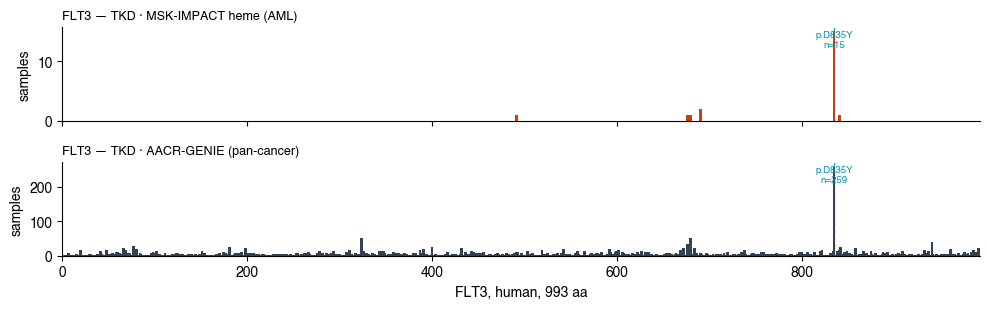

,HGVSp_Short,aa_pos,heme_samples,GENIE_samples
0,p.D835Y,835,15,259


In [186]:
# FLT3-TKD plot, only plot for missense mutations
plot_gene('FLT3', FLT3_TKD_SELECTED,
          classifications=['Missense_Mutation'], note='TKD')

## FLT3-ITD

In [187]:
# FLT3-ITD
FLT3_ITD = df_mutation[df_mutation['Hugo_Symbol'] == 'FLT3'].reset_index(drop=True)
FLT3_ITD = filter_variants(FLT3_ITD, classifications=['In_Frame_Ins'])
FLT3_ITD

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,FLT3,2322.0,NaN,GRCh37,13,28608238,28608239,+,inframe_insertion,In_Frame_Ins,...,p.T582_R607dup,ENST00000241453,NM_004119.2,582.0,cca/ccCAGAACCGGCTCCTCAGATAATGAGTACTTCTACGTTGAT...,14/24,SUCCESS,NaN,832,6
1,FLT3,2322.0,NaN,GRCh37,13,28608271,28608272,+,inframe_insertion,In_Frame_Ins,...,p.F594_R595insSSSDNEYFYVDF,ENST00000241453,NM_004119.2,595.0,aga/agCTCCTCAGATAATGAGTACTTCTACGTTGATTTCAGa,14/24,SUCCESS,NaN,813,3
2,FLT3,2322.0,NaN,GRCh37,13,28608262,28608263,+,inframe_insertion,In_Frame_Ins,...,p.Y597_E598insDYVDFREY,ENST00000241453,NM_004119.2,598.0,gaa/gaCTACGTTGATTTCAGAGAATATGAa,14/24,SUCCESS,NaN,685,3
3,FLT3,2322.0,NaN,GRCh37,13,28608323,28608324,+,inframe_insertion,In_Frame_Ins,...,p.Q577_M578insSPE,ENST00000241453,NM_004119.2,578.0,atg/aGCCCCGAGAtg,14/24,SUCCESS,NaN,878,3
4,FLT3,2322.0,NaN,GRCh37,13,28608257,28608258,+,inframe_insertion,In_Frame_Ins,...,p.G583_Y599dup,ENST00000241453,NM_004119.2,583.0,gat/gGCTCCTCAGATAATGAGTACTTCTACGTTGATTTCAGAGAA...,14/24,SUCCESS,NaN,524,3
5,FLT3,2322.0,NaN,GRCh37,13,28608255,28608256,+,inframe_insertion,In_Frame_Ins,...,p.D593_D600dup,ENST00000241453,NM_004119.2,593.0,-/GATTTCAGAGAATATGAATATGAT,14/24,SUCCESS,NaN,993,3
6,FLT3,2322.0,NaN,GRCh37,13,28608251,28608252,+,inframe_insertion,In_Frame_Ins,...,p.L601_K602insMTGSSDNEYFYVDFREYEYDL,ENST00000241453,NM_004119.2,602.0,aaa/aTGACCGGCTCCTCAGATAATGAGTACTTCTACGTTGATTTC...,14/24,SUCCESS,NaN,954,2
7,FLT3,2322.0,NaN,GRCh37,13,28608262,28608263,+,inframe_insertion,In_Frame_Ins,...,p.E598_Y599insGNNEYFYVDFREYE,ENST00000241453,NM_004119.2,598.0,gaa/gaGGGAAATAATGAGTACTTCTACGTTGATTTCAGAGAATATGAa,14/24,SUCCESS,NaN,597,2
8,FLT3,2322.0,NaN,GRCh37,13,28608257,28608258,+,inframe_insertion,In_Frame_Ins,...,p.V592_Y599dup,ENST00000241453,NM_004119.2,592.0,gat/gTTGATTTCAGAGAATATGAATATGat,14/24,SUCCESS,NaN,722,2
9,FLT3,2322.0,NaN,GRCh37,13,28608248,28608249,+,inframe_insertion,In_Frame_Ins,...,p.F594_K602dup,ENST00000241453,NM_004119.2,594.0,tgg/tTCAGAGAATATGAATATGATCTCAAATgg,14/24,SUCCESS,NaN,733,1


In [188]:
FLT3_ITD_SELECTED = FLT3_ITD.iloc[:5]  #first 5 row
FLT3_ITD_SELECTED

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,FLT3,2322.0,NaN,GRCh37,13,28608238,28608239,+,inframe_insertion,In_Frame_Ins,...,p.T582_R607dup,ENST00000241453,NM_004119.2,582.0,cca/ccCAGAACCGGCTCCTCAGATAATGAGTACTTCTACGTTGAT...,14/24,SUCCESS,NaN,832,6
1,FLT3,2322.0,NaN,GRCh37,13,28608271,28608272,+,inframe_insertion,In_Frame_Ins,...,p.F594_R595insSSSDNEYFYVDF,ENST00000241453,NM_004119.2,595.0,aga/agCTCCTCAGATAATGAGTACTTCTACGTTGATTTCAGa,14/24,SUCCESS,NaN,813,3
2,FLT3,2322.0,NaN,GRCh37,13,28608262,28608263,+,inframe_insertion,In_Frame_Ins,...,p.Y597_E598insDYVDFREY,ENST00000241453,NM_004119.2,598.0,gaa/gaCTACGTTGATTTCAGAGAATATGAa,14/24,SUCCESS,NaN,685,3
3,FLT3,2322.0,NaN,GRCh37,13,28608323,28608324,+,inframe_insertion,In_Frame_Ins,...,p.Q577_M578insSPE,ENST00000241453,NM_004119.2,578.0,atg/aGCCCCGAGAtg,14/24,SUCCESS,NaN,878,3
4,FLT3,2322.0,NaN,GRCh37,13,28608257,28608258,+,inframe_insertion,In_Frame_Ins,...,p.G583_Y599dup,ENST00000241453,NM_004119.2,583.0,gat/gGCTCCTCAGATAATGAGTACTTCTACGTTGATTTCAGAGAA...,14/24,SUCCESS,NaN,524,3


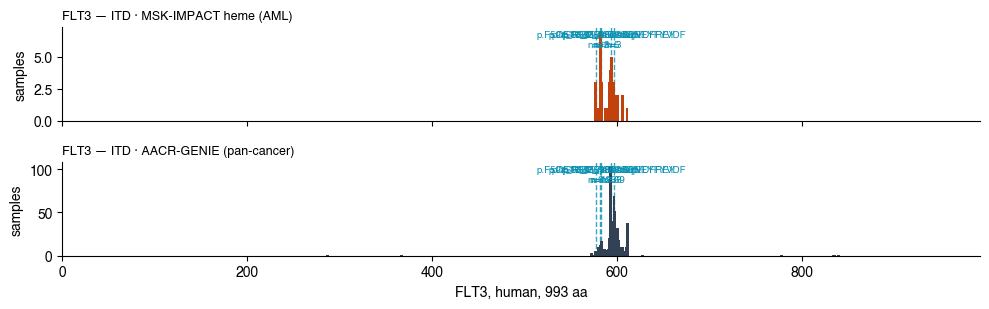

,HGVSp_Short,aa_pos,heme_samples,GENIE_samples
0,p.T582_R607dup,582,7,12
1,p.F594_R595insSSSDNEYFYVDF,594,5,38
2,p.Y597_E598insDYVDFREY,597,3,69
3,p.Q577_M578insSPE,577,3,6
4,p.G583_Y599dup,583,3,17


In [189]:
# FLT3-ITD plot, only plot for in frame insertions
plot_gene('FLT3', FLT3_ITD_SELECTED,
          classifications=['In_Frame_Ins'], note='ITD')

## NRAS

In [190]:
# NRAS
NRAS = df_mutation[df_mutation['Hugo_Symbol'] == 'NRAS'].reset_index(drop=True)
NRAS = filter_variants(NRAS)
NRAS

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,NRAS,4893.0,NaN,GRCh37,1,115258747,115258747,+,missense_variant,Missense_Mutation,...,p.G12D,ENST00000369535,NM_002524.4,12.0,gGt/gAt,2/7,SUCCESS,NaN,484,17
1,NRAS,4893.0,NaN,GRCh37,1,115258744,115258744,+,missense_variant,Missense_Mutation,...,p.G13D,ENST00000369535,NM_002524.4,13.0,gGt/gAt,2/7,SUCCESS,NaN,787,6
2,NRAS,4893.0,NaN,GRCh37,1,115256530,115256530,+,missense_variant,Missense_Mutation,...,p.Q61K,ENST00000369535,NM_002524.4,61.0,Caa/Aaa,3/7,SUCCESS,NaN,681,4
3,NRAS,4893.0,NaN,GRCh37,1,115258745,115258745,+,missense_variant,Missense_Mutation,...,p.G13R,ENST00000369535,NM_002524.4,13.0,Ggt/Cgt,2/7,SUCCESS,NaN,737,3
4,NRAS,4893.0,NaN,GRCh37,1,115258747,115258747,+,missense_variant,Missense_Mutation,...,p.G12V,ENST00000369535,NM_002524.4,12.0,gGt/gTt,2/7,SUCCESS,NaN,711,3
5,NRAS,4893.0,NaN,GRCh37,1,115258748,115258748,+,missense_variant,Missense_Mutation,...,p.G12S,ENST00000369535,NM_002524.4,12.0,Ggt/Agt,2/7,SUCCESS,NaN,590,2
6,NRAS,4893.0,NaN,GRCh37,1,115256529,115256529,+,missense_variant,Missense_Mutation,...,p.Q61R,ENST00000369535,NM_002524.4,61.0,cAa/cGa,3/7,SUCCESS,NaN,1065,2
7,NRAS,4893.0,NaN,GRCh37,1,115258748,115258748,+,missense_variant,Missense_Mutation,...,p.G12C,ENST00000369535,NM_002524.4,12.0,Ggt/Tgt,2/7,SUCCESS,NaN,968,2
8,NRAS,4893.0,NaN,GRCh37,1,115256528,115256528,+,missense_variant,Missense_Mutation,...,p.Q61H,ENST00000369535,NM_002524.4,61.0,caA/caT,3/7,SUCCESS,NaN,665,1
9,NRAS,4893.0,NaN,GRCh37,1,115256521,115256521,+,missense_variant,Missense_Mutation,...,p.Y64N,ENST00000369535,NM_002524.4,64.0,Tac/Aac,3/7,SUCCESS,NaN,869,1


In [191]:
NRAS_SELECTED = NRAS[NRAS['HGVSp_Short'].isin(['p.G12D'])].reset_index(drop=True)

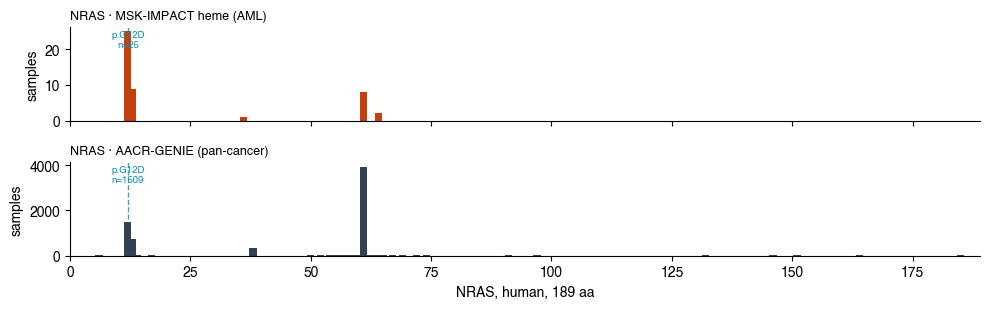

,HGVSp_Short,aa_pos,heme_samples,GENIE_samples
0,p.G12D,12,25,1509


In [192]:
# NRAS plot
plot_gene('NRAS', NRAS_SELECTED)

## KRAS

In [193]:
# KRAS
KRAS = df_mutation[df_mutation['Hugo_Symbol'] == 'KRAS'].reset_index(drop=True)
KRAS = filter_variants(KRAS)
KRAS

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,KRAS,3845.0,NaN,GRCh37,12,25398281,25398281,+,missense_variant,Missense_Mutation,...,p.G13D,ENST00000311936,NM_004985.3,13.0,gGc/gAc,2/5,SUCCESS,NaN,622,5
1,KRAS,3845.0,NaN,GRCh37,12,25398284,25398284,+,missense_variant,Missense_Mutation,...,p.G12D,ENST00000311936,NM_004985.3,12.0,gGt/gAt,2/5,SUCCESS,NaN,657,3
2,KRAS,3845.0,NaN,GRCh37,12,25398284,25398284,+,missense_variant,Missense_Mutation,...,p.G12V,ENST00000311936,NM_004985.3,12.0,gGt/gTt,2/5,SUCCESS,NaN,657,3
3,KRAS,3845.0,NaN,GRCh37,12,25398284,25398284,+,missense_variant,Missense_Mutation,...,p.G12A,ENST00000311936,NM_004985.3,12.0,gGt/gCt,2/5,SUCCESS,NaN,724,3
4,KRAS,3845.0,NaN,GRCh37,12,25380285,25380285,+,missense_variant,Missense_Mutation,...,p.T58I,ENST00000311936,NM_004985.3,58.0,aCa/aTa,3/5,SUCCESS,NaN,747,3
5,KRAS,3845.0,NaN,GRCh37,12,25380279,25380279,+,missense_variant,Missense_Mutation,...,p.G60D,ENST00000311936,NM_004985.3,60.0,gGt/gAt,3/5,SUCCESS,NaN,468,2
6,KRAS,3845.0,NaN,GRCh37,12,25380254,25380254,+,missense_variant,Missense_Mutation,...,p.R68S,ENST00000311936,NM_004985.3,68.0,agG/agT,3/5,SUCCESS,NaN,713,1
7,KRAS,3845.0,NaN,GRCh37,12,25398280,25398281,+,inframe_insertion,In_Frame_Ins,...,p.G13dup,ENST00000311936,NM_004985.3,13.0,ggc/ggTGGc,2/5,SUCCESS,NaN,607,1
8,KRAS,3845.0,NaN,GRCh37,12,25380275,25380275,+,missense_variant,Missense_Mutation,...,p.Q61H,ENST00000311936,NM_004985.3,61.0,caA/caC,3/5,SUCCESS,NaN,955,1


In [194]:
KRAS_SELECTED = KRAS[KRAS['HGVSp_Short'].isin(['p.G12D'])].reset_index(drop=True)
KRAS_SELECTED

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,KRAS,3845.0,NaN,GRCh37,12,25398284,25398284,+,missense_variant,Missense_Mutation,...,p.G12D,ENST00000311936,NM_004985.3,12.0,gGt/gAt,2/5,SUCCESS,NaN,657,3


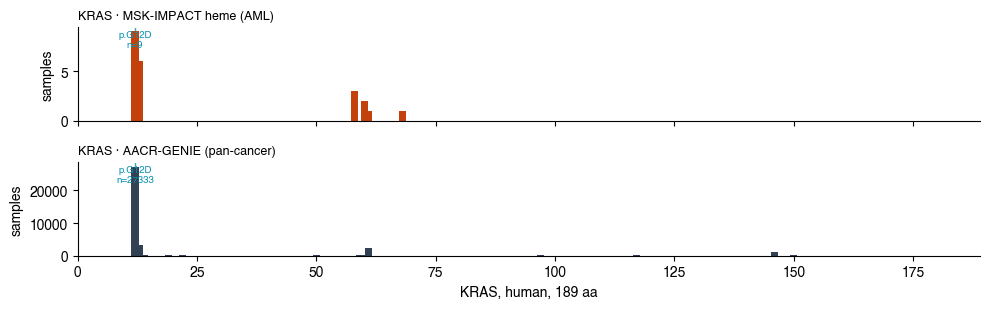

,HGVSp_Short,aa_pos,heme_samples,GENIE_samples
0,p.G12D,12,9,27333


In [195]:
# KRAS plot
plot_gene('KRAS', KRAS_SELECTED)

## KIT

In [196]:
# KIT
KIT = df_mutation[df_mutation['Hugo_Symbol'] == 'KIT'].reset_index(drop=True)
KIT = filter_variants(KIT)
KIT

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,KIT,3815.0,NaN,GRCh37,4,55599340,55599340,+,missense_variant,Missense_Mutation,...,p.N822K,ENST00000288135,NM_000222.2,822.0,aaT/aaA,17/21,SUCCESS,NaN,709,2
1,KIT,3815.0,NaN,GRCh37,4,55599321,55599321,+,missense_variant,Missense_Mutation,...,p.D816V,ENST00000288135,NM_000222.2,816.0,gAc/gTc,17/21,SUCCESS,NaN,709,2
2,KIT,3815.0,NaN,GRCh37,4,55599320,55599320,+,missense_variant,Missense_Mutation,...,p.D816H,ENST00000288135,NM_000222.2,816.0,Gac/Cac,17/21,SUCCESS,NaN,490,2


In [197]:
KIT_SELECTED = KIT[KIT['HGVSp_Short'].isin(['p.D816V'])].reset_index(drop=True)
KIT_SELECTED

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,KIT,3815.0,NaN,GRCh37,4,55599321,55599321,+,missense_variant,Missense_Mutation,...,p.D816V,ENST00000288135,NM_000222.2,816.0,gAc/gTc,17/21,SUCCESS,NaN,709,2


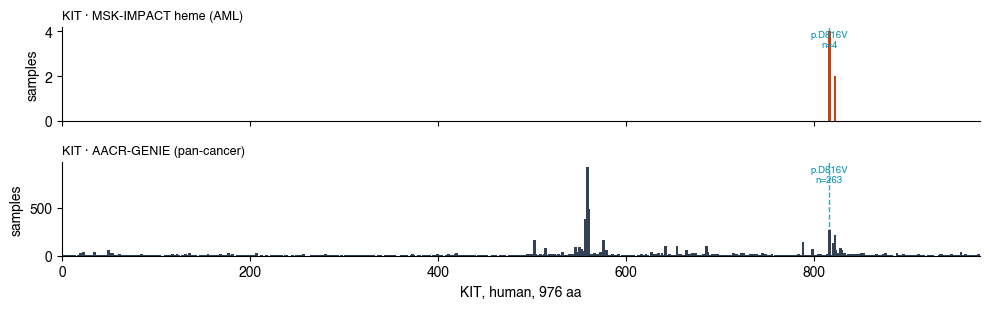

,HGVSp_Short,aa_pos,heme_samples,GENIE_samples
0,p.D816V,816,4,263


In [198]:
# KIT plot
plot_gene('KIT', KIT_SELECTED)

## PTPN11

In [199]:
# PTPN11
PTPN11 = df_mutation[df_mutation['Hugo_Symbol'] == 'PTPN11'].reset_index(drop=True)
PTPN11 = filter_variants(PTPN11)
PTPN11

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,PTPN11,5781.0,NaN,GRCh37,12,112888163,112888163,+,missense_variant,Missense_Mutation,...,p.G60V,ENST00000351677,NM_002834.3,60.0,gGt/gTt,3/16,SUCCESS,NaN,518,5
1,PTPN11,5781.0,NaN,GRCh37,12,112888166,112888166,+,missense_variant,Missense_Mutation,...,p.D61G,ENST00000351677,NM_002834.3,61.0,gAt/gGt,3/16,SUCCESS,NaN,786,4
2,PTPN11,5781.0,NaN,GRCh37,12,112888199,112888199,+,missense_variant,Missense_Mutation,...,p.A72V,ENST00000351677,NM_002834.3,72.0,gCc/gTc,3/16,SUCCESS,NaN,933,2
3,PTPN11,5781.0,NaN,GRCh37,12,112888210,112888210,+,missense_variant,Missense_Mutation,...,p.E76K,ENST00000351677,NM_002834.3,76.0,Gag/Aag,3/16,SUCCESS,NaN,584,2
4,PTPN11,5781.0,NaN,GRCh37,12,112926851,112926851,+,missense_variant,Missense_Mutation,...,p.P491T,ENST00000351677,NM_002834.3,491.0,Ccc/Acc,13/16,SUCCESS,NaN,1019,2
5,PTPN11,5781.0,NaN,GRCh37,12,112888162,112888166,+,missense_variant,Missense_Mutation,...,p.G60_D61delinsTC,ENST00000351677,NM_002834.3,60.0,GGTGAt/ACATGt,3/16,SUCCESS,NaN,922,2
6,PTPN11,5781.0,NaN,GRCh37,12,112910785,112910785,+,missense_variant,Missense_Mutation,...,p.R265Q,ENST00000351677,NM_002834.3,265.0,cGa/cAa,7/16,SUCCESS,NaN,604,2
7,PTPN11,5781.0,NaN,GRCh37,12,112926888,112926888,+,missense_variant,Missense_Mutation,...,p.G503V,ENST00000351677,NM_002834.3,503.0,gGg/gTg,13/16,SUCCESS,NaN,591,1
8,PTPN11,5781.0,NaN,GRCh37,12,112926884,112926884,+,missense_variant,Missense_Mutation,...,p.S502P,ENST00000351677,NM_002834.3,502.0,Tca/Cca,13/16,SUCCESS,NaN,772,1
9,PTPN11,5781.0,NaN,GRCh37,12,112926888,112926888,+,missense_variant,Missense_Mutation,...,p.G503A,ENST00000351677,NM_002834.3,503.0,gGg/gCg,13/16,SUCCESS,NaN,763,1


In [200]:
PTPN11_SELECTED = PTPN11[PTPN11['HGVSp_Short'].isin(['p.G60V','p.E76K'])].reset_index(drop=True)
PTPN11_SELECTED

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,PTPN11,5781.0,NaN,GRCh37,12,112888163,112888163,+,missense_variant,Missense_Mutation,...,p.G60V,ENST00000351677,NM_002834.3,60.0,gGt/gTt,3/16,SUCCESS,NaN,518,5
1,PTPN11,5781.0,NaN,GRCh37,12,112888210,112888210,+,missense_variant,Missense_Mutation,...,p.E76K,ENST00000351677,NM_002834.3,76.0,Gag/Aag,3/16,SUCCESS,NaN,584,2


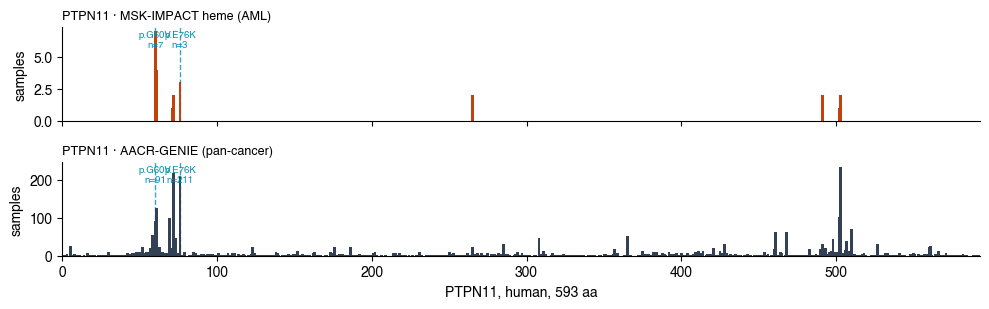

,HGVSp_Short,aa_pos,heme_samples,GENIE_samples
0,p.G60V,60,7,91
1,p.E76K,76,3,211


In [201]:
# PTPN11 plot
plot_gene('PTPN11', PTPN11_SELECTED)

## NPM1

In [202]:
# NPM1
NPM1 = df_mutation[df_mutation['Hugo_Symbol'] == 'NPM1'].reset_index(drop=True)
NPM1 = filter_variants(NPM1)
NPM1

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,NPM1,4869.0,NaN,GRCh37,5,170837543,170837544,+,frameshift_variant,Frame_Shift_Ins,...,p.W288Cfs*12,ENST00000296930,NM_002520.6,287.0,ctc/cTCTGtc,11/11,SUCCESS,NaN,173,30
1,NPM1,4869.0,NaN,GRCh37,5,170837544,170837545,+,frameshift_variant,Frame_Shift_Ins,...,p.W288Cfs*12,ENST00000296930,NM_002520.6,287.0,ctc/ctCTGCc,11/11,SUCCESS,NaN,185,7
2,NPM1,4869.0,NaN,GRCh37,5,170837545,170837546,+,frameshift_variant,Frame_Shift_Ins,...,p.W288Cfs*12,ENST00000296930,NM_002520.6,287.0,-/TGCA,11/11,SUCCESS,NaN,114,4
3,NPM1,4869.0,NaN,GRCh37,5,170837545,170837546,+,frameshift_variant,Frame_Shift_Ins,...,p.W288Cfs*12,ENST00000296930,NM_002520.6,287.0,-/TGCT,11/11,SUCCESS,NaN,168,3
4,NPM1,4869.0,NaN,GRCh37,5,170819946,170819946,+,missense_variant,Missense_Mutation,...,p.D163G,ENST00000296930,NM_002520.6,163.0,gAt/gGt,6/11,SUCCESS,NaN,573,1
5,NPM1,4869.0,NaN,GRCh37,5,170837547,170837548,+,frameshift_variant,Frame_Shift_Ins,...,p.W288Cfs*12,ENST00000296930,NM_002520.6,288.0,tgg/tgCAGAg,11/11,SUCCESS,NaN,305,1
6,NPM1,4869.0,NaN,GRCh37,5,170837548,170837548,+,missense_variant,Missense_Mutation,...,p.W288C,ENST00000296930,NM_002520.6,288.0,tgG/tgC,11/11,SUCCESS,NaN,122,1
7,NPM1,4869.0,NaN,GRCh37,5,170827192,170827192,+,missense_variant,Missense_Mutation,...,p.E187V,ENST00000296930,NM_002520.6,187.0,gAa/gTa,7/11,SUCCESS,NaN,366,1
8,NPM1,4869.0,NaN,GRCh37,5,170827192,170827193,+,frameshift_variant,Frame_Shift_Ins,...,p.K189Afs*52,ENST00000296930,NM_002520.6,187.0,gaa/gaGGAAGCTGGAACTa,7/11,SUCCESS,NaN,400,1


In [203]:
NPM1_SELECTED = NPM1.iloc[:3]
NPM1_SELECTED

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,NPM1,4869.0,NaN,GRCh37,5,170837543,170837544,+,frameshift_variant,Frame_Shift_Ins,...,p.W288Cfs*12,ENST00000296930,NM_002520.6,287.0,ctc/cTCTGtc,11/11,SUCCESS,NaN,173,30
1,NPM1,4869.0,NaN,GRCh37,5,170837544,170837545,+,frameshift_variant,Frame_Shift_Ins,...,p.W288Cfs*12,ENST00000296930,NM_002520.6,287.0,ctc/ctCTGCc,11/11,SUCCESS,NaN,185,7
2,NPM1,4869.0,NaN,GRCh37,5,170837545,170837546,+,frameshift_variant,Frame_Shift_Ins,...,p.W288Cfs*12,ENST00000296930,NM_002520.6,287.0,-/TGCA,11/11,SUCCESS,NaN,114,4


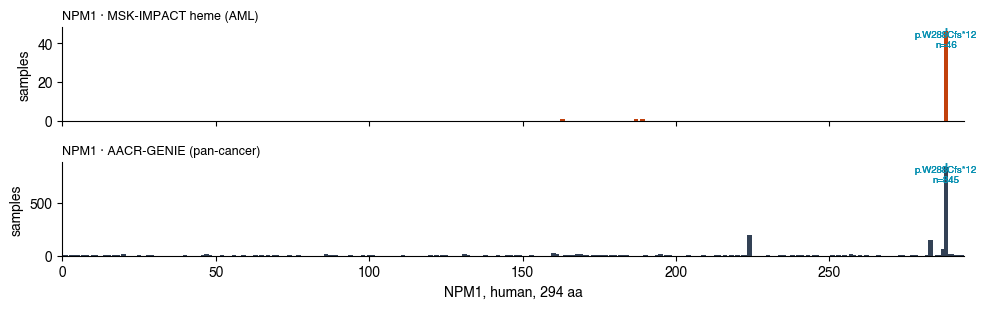

,HGVSp_Short,aa_pos,heme_samples,GENIE_samples
0,p.W288Cfs*12,288,46,845
1,p.W288Cfs*12,288,46,845
2,p.W288Cfs*12,288,46,845


In [204]:
# NPM1 plot
plot_gene('NPM1', NPM1_SELECTED)

## RUNX1

In [205]:
# RUNX1
RUNX1 = df_mutation[df_mutation['Hugo_Symbol'] == 'RUNX1'].reset_index(drop=True)
RUNX1 = filter_variants(RUNX1)
RUNX1

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,RUNX1,861.0,NaN,GRCh37,21,36231835,36231836,+,frameshift_variant,Frame_Shift_Ins,...,p.P184Tfs*29,ENST00000300305,NaN,183.0,cca/ccCa,5/8,SUCCESS,NaN,2198,6
1,RUNX1,861.0,NaN,GRCh37,21,36231792,36231792,+,missense_variant,Missense_Mutation,...,p.D198N,ENST00000300305,NaN,198.0,Gat/Aat,5/8,SUCCESS,NaN,1445,5
2,RUNX1,861.0,NaN,GRCh37,21,36164686,36164687,+,frameshift_variant,Frame_Shift_Ins,...,p.Q397Kfs*205,ENST00000300305,NaN,396.0,-/AAAGCCC,8/8,SUCCESS,NaN,1073,5
3,RUNX1,861.0,NaN,GRCh37,21,36252865,36252865,+,missense_variant,Missense_Mutation,...,p.R166Q,ENST00000300305,NaN,166.0,cGa/cAa,4/8,SUCCESS,NaN,893,4
4,RUNX1,861.0,NaN,GRCh37,21,36231782,36231782,+,missense_variant,Missense_Mutation,...,p.R201Q,ENST00000300305,NaN,201.0,cGa/cAa,5/8,SUCCESS,NaN,872,4
5,RUNX1,861.0,NaN,GRCh37,21,36252877,36252877,+,missense_variant,Missense_Mutation,...,p.R162K,ENST00000300305,NaN,162.0,aGg/aAg,4/8,SUCCESS,NaN,714,3
6,RUNX1,861.0,NaN,GRCh37,21,36252866,36252866,+,stop_gained,Nonsense_Mutation,...,p.R166*,ENST00000300305,NaN,166.0,Cga/Tga,4/8,SUCCESS,NaN,486,3
7,RUNX1,861.0,NaN,GRCh37,21,36206762,36206763,+,frameshift_variant,Frame_Shift_Ins,...,p.A251Lfs*6,ENST00000300305,NaN,250.0,cgt/cgGTTGACCCt,6/8,SUCCESS,NaN,1261,3
8,RUNX1,861.0,NaN,GRCh37,21,36259199,36259199,+,frameshift_variant,Frame_Shift_Del,...,p.L98Sfs*24,ENST00000300305,NaN,98.0,Ctc/tc,3/8,SUCCESS,NaN,886,3
9,RUNX1,861.0,NaN,GRCh37,21,36252923,36252949,+,inframe_deletion,In_Frame_Del,...,p.E138_N146del,ENST00000300305,NaN,138.0,gAAAACTACTCGGCTGAGCTGAGAAATGct/gct,4/8,SUCCESS,NaN,438,3


In [206]:
RUNX1_SELECTED = RUNX1[RUNX1['HGVSp_Short'].isin(['p.R201Q','p.D198N','p.P184Tfs*29'])].reset_index(drop=True)
RUNX1_SELECTED

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Exon_Number,Annotation_Status,n_depth,t_depth,count
0,RUNX1,861.0,NaN,GRCh37,21,36231835,36231836,+,frameshift_variant,Frame_Shift_Ins,...,p.P184Tfs*29,ENST00000300305,NaN,183.0,cca/ccCa,5/8,SUCCESS,NaN,2198,6
1,RUNX1,861.0,NaN,GRCh37,21,36231792,36231792,+,missense_variant,Missense_Mutation,...,p.D198N,ENST00000300305,NaN,198.0,Gat/Aat,5/8,SUCCESS,NaN,1445,5
2,RUNX1,861.0,NaN,GRCh37,21,36231782,36231782,+,missense_variant,Missense_Mutation,...,p.R201Q,ENST00000300305,NaN,201.0,cGa/cAa,5/8,SUCCESS,NaN,872,4


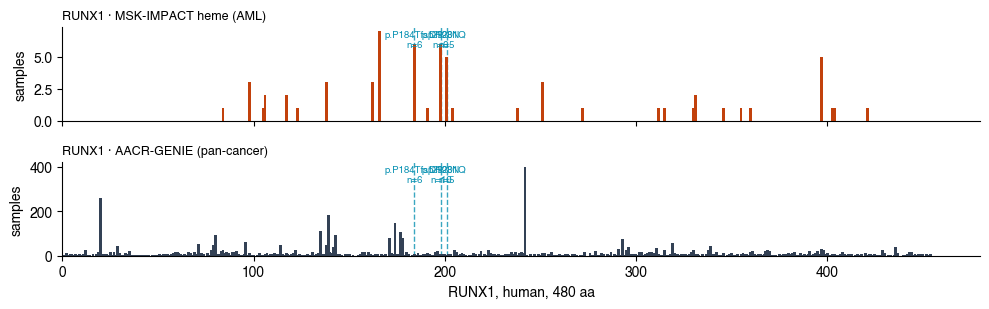

,HGVSp_Short,aa_pos,heme_samples,GENIE_samples
0,p.P184Tfs*29,184,6,6
1,p.D198N,198,6,10
2,p.R201Q,201,5,5


In [207]:
# RUNX1 plot
plot_gene('RUNX1', RUNX1_SELECTED)

## WT1

In [208]:
# WT1
WT1 = df_mutation_genie[df_mutation_genie['Hugo_Symbol'] == 'WT1'].reset_index(drop=True)
WT1 = filter_variants(WT1)
WT1

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,Polyphen_Prediction,Polyphen_Score,SIFT_Prediction,SIFT_Score,SWISSPROT,n_depth,t_depth,Annotation_Status,mutationInCis_Flag,count
0,WT1,7490.0,UCHI,GRCh37,11,32449417,32449417,+,intron_variant,Intron,...,NaN,NaN,NaN,NaN,NaN,NaN,3049.0,SUCCESS,False,96
1,WT1,7490.0,UCHI,GRCh37,11,32449420,32449420,+,intron_variant,Intron,...,NaN,NaN,NaN,NaN,NaN,NaN,2935.0,SUCCESS,False,95
2,WT1,7490.0,DFCI,GRCh37,11,32417907,32417908,+,frameshift_variant,Frame_Shift_Ins,...,NaN,NaN,NaN,NaN,NaN,NaN,790.0,SUCCESS,False,45
3,WT1,7490.0,DFCI,GRCh37,11,32413565,32413565,+,missense_variant,Missense_Mutation,...,probably_damaging,0.997,deleterious_low_confidence,0.03,NaN,NaN,270.0,SUCCESS,False,34
4,WT1,7490.0,DFCI,GRCh37,11,32413566,32413566,+,missense_variant,Missense_Mutation,...,probably_damaging,1.000,deleterious_low_confidence,0.00,NaN,NaN,165.0,SUCCESS,False,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1722,WT1,7490.0,MSK,GRCh37,11,32456403,32456403,+,missense_variant,Missense_Mutation,...,probably_damaging,0.950,deleterious_low_confidence,0.00,NaN,467.0,252.0,SUCCESS,False,1
1723,WT1,7490.0,MSK,GRCh37,11,32449531,32449531,+,missense_variant,Missense_Mutation,...,probably_damaging,0.932,deleterious_low_confidence,0.00,NaN,356.0,305.0,SUCCESS,False,1
1724,WT1,7490.0,MSK,GRCh37,11,32449554,32449554,+,missense_variant,Missense_Mutation,...,benign,0.123,tolerated_low_confidence,0.19,NaN,495.0,952.0,SUCCESS,False,1
1725,WT1,7490.0,MSK,GRCh37,11,32417909,32417910,+,frameshift_variant,Frame_Shift_Ins,...,NaN,NaN,NaN,NaN,NaN,1577.0,1106.0,SUCCESS,False,1


In [209]:
WT1_SELECTED = WT1[WT1['HGVSp_Short'].isin(['p.T358M','p.R462W','p.R462Q'])].reset_index(drop=True)
WT1_SELECTED

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,Polyphen_Prediction,Polyphen_Score,SIFT_Prediction,SIFT_Score,SWISSPROT,n_depth,t_depth,Annotation_Status,mutationInCis_Flag,count
0,WT1,7490.0,DFCI,GRCh37,11,32413565,32413565,+,missense_variant,Missense_Mutation,...,probably_damaging,0.997,deleterious_low_confidence,0.03,NaN,NaN,270.0,SUCCESS,False,34
1,WT1,7490.0,DFCI,GRCh37,11,32413566,32413566,+,missense_variant,Missense_Mutation,...,probably_damaging,1.000,deleterious_low_confidence,0.00,NaN,NaN,165.0,SUCCESS,False,29
2,WT1,7490.0,DFCI,GRCh37,11,32421519,32421519,+,missense_variant,Missense_Mutation,...,probably_damaging,0.988,deleterious_low_confidence,0.00,NaN,NaN,326.0,SUCCESS,False,29
3,WT1,7490.0,DFCI,GRCh37,11,32413564,32413565,+,missense_variant,Missense_Mutation,...,probably_damaging,0.997,deleterious_low_confidence,0.03,NaN,NaN,246.0,SUCCESS,False,1


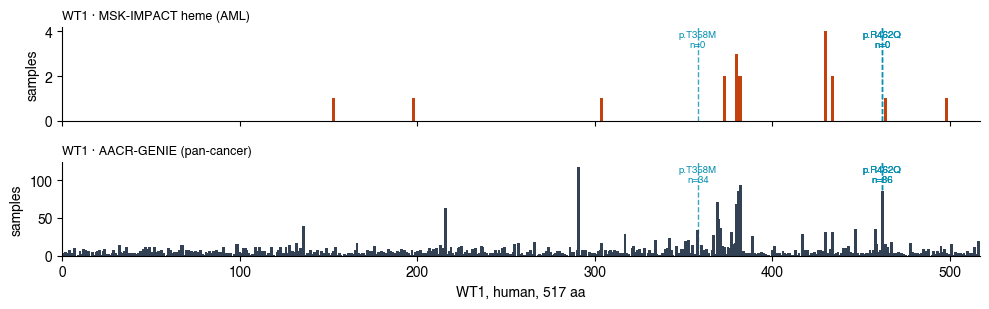

,HGVSp_Short,aa_pos,heme_samples,GENIE_samples
0,p.R462Q,462,0,86
1,p.R462Q,462,0,86
2,p.T358M,358,0,34
3,p.R462Q,462,0,86


In [210]:
# WT1 plot
plot_gene('WT1', WT1_SELECTED)

# Put all selected mutations together


In [293]:
SELECTED_MUTATIONS = pd.concat([
    DNMT3A_SELECTED, TET2_SELECTED, ASXL1_SELECTED, IDH1_SELECTED, IDH2_SELECTED, SF3B1_SELECTED, SRSF2_SELECTED,
    U2AF1_SELECTED, JAK2_SELECTED, TP53_SELECTED, PPM1D_SELECTED, FLT3_TKD_SELECTED, FLT3_ITD_SELECTED, NRAS_SELECTED,
    KRAS_SELECTED, KIT_SELECTED, PTPN11_SELECTED, NPM1_SELECTED, RUNX1_SELECTED, WT1_SELECTED
], ignore_index=True)   

SELECTED_MUTATIONS

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,gnomAD_NFE_AF,gnomAD_OTH_AF,gnomAD_SAS_AF,FILTER,Polyphen_Prediction,Polyphen_Score,SIFT_Prediction,SIFT_Score,SWISSPROT,mutationInCis_Flag
0,DNMT3A,1788.0,NaN,GRCh37,2,25457242,25457242,+,missense_variant,Missense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,DNMT3A,1788.0,NaN,GRCh37,2,25467468,25467468,+,stop_gained,Nonsense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,DNMT3A,1788.0,NaN,GRCh37,2,25463182,25463182,+,stop_gained,Nonsense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TET2,54790.0,NaN,GRCh37,4,106193995,106193995,+,stop_gained,Nonsense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TET2,54790.0,NaN,GRCh37,4,106157054,106157054,+,frameshift_variant,Frame_Shift_Del,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ASXL1,171023.0,NaN,GRCh37,20,31022441,31022442,+,frameshift_variant,Frame_Shift_Ins,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ASXL1,171023.0,NaN,GRCh37,20,31022548,31022548,+,frameshift_variant,Frame_Shift_Del,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ASXL1,171023.0,NaN,GRCh37,20,31022592,31022592,+,stop_gained,Nonsense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,IDH1,3417.0,NaN,GRCh37,2,209113112,209113112,+,missense_variant,Missense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,IDH2,3418.0,NaN,GRCh37,15,90631934,90631934,+,missense_variant,Missense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# H2M

In [257]:
import bioh2m as h2m

In [228]:
path_h_ref, path_m_ref = '/Users/kexindong/Documents/GitHub/Database/RefGenome/ncbi-2023-09-12/GCF_000001405.25_GRCh37.p13_genomic.fna.gz', '/Users/kexindong/Documents/GitHub/Database/RefGenome/mouse-2023-09-13/GCF_000001635.27_GRCm39_genomic.fna.gz'
# remember to replace the paths with yours
records_h, index_list_h = h2m.genome_loader(path_h_ref)
records_m, index_list_m  = h2m.genome_loader(path_m_ref)
path_h_anno, path_m_anno = '/Users/kexindong/Documents/GitHub/Database/Genecode/gencode_v19_GRCh37.db', '/Users/kexindong/Documents/GitHub/Database/Genecode/gencode_vm33_GRCm39.db'
# remember to replace the paths with yours
db_h, db_m = h2m.anno_loader(path_h_anno), h2m.anno_loader(path_m_anno)

In [294]:
df = SELECTED_MUTATIONS.copy()
df = df.rename(columns={'Hugo_Symbol': 'gene_name_h'})
df, df_fail = h2m.get_tx_batch(df, species='h', ver = 37)

No error occurs.


In [295]:
df

,gene_name_h,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,gnomAD_SAS_AF,FILTER,Polyphen_Prediction,Polyphen_Score,SIFT_Prediction,SIFT_Score,SWISSPROT,mutationInCis_Flag,tx_id_h,ref_genome_h
0,DNMT3A,1788.0,NaN,GRCh37,2,25457242,25457242,+,missense_variant,Missense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000264709.3,GRCh37
1,DNMT3A,1788.0,NaN,GRCh37,2,25467468,25467468,+,stop_gained,Nonsense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000264709.3,GRCh37
2,DNMT3A,1788.0,NaN,GRCh37,2,25463182,25463182,+,stop_gained,Nonsense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000264709.3,GRCh37
3,TET2,54790.0,NaN,GRCh37,4,106193995,106193995,+,stop_gained,Nonsense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000540549.1,GRCh37
4,TET2,54790.0,NaN,GRCh37,4,106157054,106157054,+,frameshift_variant,Frame_Shift_Del,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000540549.1,GRCh37
5,ASXL1,171023.0,NaN,GRCh37,20,31022441,31022442,+,frameshift_variant,Frame_Shift_Ins,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000375687.4,GRCh37
6,ASXL1,171023.0,NaN,GRCh37,20,31022548,31022548,+,frameshift_variant,Frame_Shift_Del,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000375687.4,GRCh37
7,ASXL1,171023.0,NaN,GRCh37,20,31022592,31022592,+,stop_gained,Nonsense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000375687.4,GRCh37
8,IDH1,3417.0,NaN,GRCh37,2,209113112,209113112,+,missense_variant,Missense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000415913.1,GRCh37
9,IDH2,3418.0,NaN,GRCh37,15,90631934,90631934,+,missense_variant,Missense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000330062.3,GRCh37


In [296]:
df_queried, df_fail = h2m.query_batch(df, direction='h2m')

No error occurs.


In [297]:
df_queried

,gene_name_h,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,FILTER,Polyphen_Prediction,Polyphen_Score,SIFT_Prediction,SIFT_Score,SWISSPROT,mutationInCis_Flag,tx_id_h,ref_genome_h,gene_name_m
0,ASXL1,171023.0,NaN,GRCh37,20,31022441,31022442,+,frameshift_variant,Frame_Shift_Ins,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000375687.4,GRCh37,Asxl1
1,ASXL1,171023.0,NaN,GRCh37,20,31022548,31022548,+,frameshift_variant,Frame_Shift_Del,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000375687.4,GRCh37,Asxl1
2,ASXL1,171023.0,NaN,GRCh37,20,31022592,31022592,+,stop_gained,Nonsense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000375687.4,GRCh37,Asxl1
3,DNMT3A,1788.0,NaN,GRCh37,2,25457242,25457242,+,missense_variant,Missense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000264709.3,GRCh37,Dnmt3a
4,DNMT3A,1788.0,NaN,GRCh37,2,25467468,25467468,+,stop_gained,Nonsense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000264709.3,GRCh37,Dnmt3a
5,DNMT3A,1788.0,NaN,GRCh37,2,25463182,25463182,+,stop_gained,Nonsense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000264709.3,GRCh37,Dnmt3a
6,FLT3,2322.0,NaN,GRCh37,13,28592642,28592642,+,missense_variant,Missense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000241453.7,GRCh37,Flt3
7,FLT3,2322.0,NaN,GRCh37,13,28608238,28608239,+,inframe_insertion,In_Frame_Ins,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000241453.7,GRCh37,Flt3
8,FLT3,2322.0,NaN,GRCh37,13,28608271,28608272,+,inframe_insertion,In_Frame_Ins,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000241453.7,GRCh37,Flt3
9,FLT3,2322.0,NaN,GRCh37,13,28608262,28608263,+,inframe_insertion,In_Frame_Ins,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000241453.7,GRCh37,Flt3


In [298]:
df_queried, df_fail = h2m.get_tx_batch(df_queried, species='m')

No error occurs.


In [299]:
df_queried

,gene_name_h,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,Polyphen_Prediction,Polyphen_Score,SIFT_Prediction,SIFT_Score,SWISSPROT,mutationInCis_Flag,tx_id_h,ref_genome_h,gene_name_m,tx_id_m
0,ASXL1,171023.0,NaN,GRCh37,20,31022441,31022442,+,frameshift_variant,Frame_Shift_Ins,...,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000375687.4,GRCh37,Asxl1,ENSMUST00000109790.2
1,ASXL1,171023.0,NaN,GRCh37,20,31022548,31022548,+,frameshift_variant,Frame_Shift_Del,...,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000375687.4,GRCh37,Asxl1,ENSMUST00000109790.2
2,ASXL1,171023.0,NaN,GRCh37,20,31022592,31022592,+,stop_gained,Nonsense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000375687.4,GRCh37,Asxl1,ENSMUST00000109790.2
3,DNMT3A,1788.0,NaN,GRCh37,2,25457242,25457242,+,missense_variant,Missense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000264709.3,GRCh37,Dnmt3a,ENSMUST00000020991.15
4,DNMT3A,1788.0,NaN,GRCh37,2,25467468,25467468,+,stop_gained,Nonsense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000264709.3,GRCh37,Dnmt3a,ENSMUST00000020991.15
5,DNMT3A,1788.0,NaN,GRCh37,2,25463182,25463182,+,stop_gained,Nonsense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000264709.3,GRCh37,Dnmt3a,ENSMUST00000020991.15
6,FLT3,2322.0,NaN,GRCh37,13,28592642,28592642,+,missense_variant,Missense_Mutation,...,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000241453.7,GRCh37,Flt3,ENSMUST00000049324.13
7,FLT3,2322.0,NaN,GRCh37,13,28608238,28608239,+,inframe_insertion,In_Frame_Ins,...,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000241453.7,GRCh37,Flt3,ENSMUST00000049324.13
8,FLT3,2322.0,NaN,GRCh37,13,28608271,28608272,+,inframe_insertion,In_Frame_Ins,...,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000241453.7,GRCh37,Flt3,ENSMUST00000049324.13
9,FLT3,2322.0,NaN,GRCh37,13,28608262,28608263,+,inframe_insertion,In_Frame_Ins,...,NaN,NaN,NaN,NaN,NaN,NaN,ENST00000241453.7,GRCh37,Flt3,ENSMUST00000049324.13


In [300]:
df_queried.columns

Index(['gene_name_h', 'Entrez_Gene_Id', 'Center', 'NCBI_Build', 'Chromosome',
       'Start_Position', 'End_Position', 'Strand', 'Consequence',
       'Variant_Classification', 'Variant_Type', 'Reference_Allele',
       'Tumor_Seq_Allele1', 'Tumor_Seq_Allele2', 'dbSNP_RS',
       'dbSNP_Val_Status', 'Tumor_Sample_Barcode',
       'Matched_Norm_Sample_Barcode', 'Match_Norm_Seq_Allele1',
       'Match_Norm_Seq_Allele2', 'Tumor_Validation_Allele1',
       'Tumor_Validation_Allele2', 'Match_Norm_Validation_Allele1',
       'Match_Norm_Validation_Allele2', 'Verification_Status',
       'Validation_Status', 'Mutation_Status', 'Sequencing_Phase',
       'Sequence_Source', 'Validation_Method', 'Score', 'BAM_File',
       'Sequencer', 't_ref_count', 't_alt_count', 'n_ref_count', 'n_alt_count',
       'HGVSc', 'HGVSp', 'HGVSp_Short', 'Transcript_ID', 'RefSeq',
       'Protein_position', 'Codons', 'Exon_Number', 'Annotation_Status',
       'n_depth', 't_depth', 'count', 'gnomAD_AF', 'gnomAD_AFR_A

In [301]:
df_queried = df_queried.rename(columns={'Start_Position': 'start', 
                                        'End_Position': 'end', 
                                        'Variant_Type': 'type', 
                                        'Reference_Allele': 'ref_seq', 
                                        'Tumor_Seq_Allele2': 'alt_seq'})
df_queried['index'] = df_queried.index

In [302]:
df_result, df_fail = h2m.model_batch(df_queried, records_h, index_list_h, records_m, index_list_m, db_h, db_m, 37)

No error occurs.


In [303]:
df_result[df_result['status']==False]

,gene_name_h,gene_id_h,tx_id_h,chr_h,exon_num_h,strand_h,match,start_h,end_h,ref_seq_h,...,alt_seq_m_ori,HGVSc_m_ori,HGVSp_m_ori,start_m,end_m,ref_seq_m,alt_seq_m,HGVSc_m,HGVSp_m,index


In [304]:
df_result[df_result['status']==True]

,gene_name_h,gene_id_h,tx_id_h,chr_h,exon_num_h,strand_h,match,start_h,end_h,ref_seq_h,...,alt_seq_m_ori,HGVSc_m_ori,HGVSp_m_ori,start_m,end_m,ref_seq_m,alt_seq_m,HGVSc_m,HGVSp_m,index
0,ASXL1,ENSG00000171456.12,ENST00000375687.4,chr20,13,+,True,31022441,31022442,-,...,G,ENSMUST00000109790.2:c.1917_1918>G,G643Wfs*14,153241365,153241366,-,G,ENSMUST00000109790.2:c.1917_1918>G,G643Wfs*14,0
1,ASXL1,ENSG00000171456.12,ENST00000375687.4,chr20,13,+,True,31022548,31022548,G,...,-,ENSMUST00000109790.2:c.2024G>,G676Efs*24,153241472,153241472,G,-,ENSMUST00000109790.2:c.2024G>,G676Efs*24,1
2,ASXL1,ENSG00000171456.12,ENST00000375687.4,chr20,13,+,True,31022592,31022592,C,...,T,ENSMUST00000109790.2:c.2068C>T,R690*,153241516,153241516,C,T,ENSMUST00000109790.2:c.2068C>T,R690*,2
3,DNMT3A,ENSG00000119772.12,ENST00000264709.3,chr2,22,-,True,25457242,25457242,C,...,A,ENSMUST00000020991.15:c.2633G>A,R878H,3957653,3957653,G,A,ENSMUST00000020991.15:c.2633G>A,R878H,3
4,DNMT3A,ENSG00000119772.12,ENST00000264709.3,chr2,22,-,True,25467468,25467468,G,...,G,ENSMUST00000020991.15:c.1596T>G,Y532*,3949640,3949640,T,G,ENSMUST00000020991.15:c.1596T>G,Y532*,4
5,DNMT3A,ENSG00000119772.12,ENST00000264709.3,chr2,22,-,True,25463182,25463182,G,...,T,ENSMUST00000020991.15:c.2299C>T,R767*,3952803,3952803,C,T,ENSMUST00000020991.15:c.2299C>T,R767*,5
6,FLT3,ENSG00000122025.10,ENST00000241453.7,chr13,24,-,True,28592642,28592642,C,...,A,ENSMUST00000049324.13:c.2512G>T,D838Y,147278061,147278061,C,A,ENSMUST00000049324.13:c.2512G>T,D838Y,6
7,FLT3,ENSG00000122025.10,ENST00000241453.7,chr13,24,-,True,28608238,28608239,-,...,GGAAACTCCCATTTGAGATCATATTCATATTCTCTGAAATCAACGT...,ENSMUST00000049324.13:c.1820_1821>CAGAACCGGCTC...,P607_R608insRTGSSDNEYFYVDFREYEYDLKWEFP,147291628,147291629,-,GGAAACTCCCATTTGAGATCATATTCATATTCTCTGAAATCAACGT...,ENSMUST00000049324.13:c.1820_1821>CAGAACCGGCTC...,P607_R608insRTGSSDNEYFYVDFREYEYDLKWEFP,7
8,FLT3,ENSG00000122025.10,ENST00000241453.7,chr13,24,-,True,28608271,28608272,-,...,CTGAAATCAACGTAGAAGTACTCATTATCTGAGGAG,ENSMUST00000049324.13:c.1787_1788>CTCCTCAGATAA...,F595_R596insSSSDNEYFYVDF,147291661,147291662,-,CTGAAATCAACGTAGAAGTACTCATTATCTGAGGAG,ENSMUST00000049324.13:c.1787_1788>CTCCTCAGATAA...,F595_R596insSSSDNEYFYVDF,8
9,FLT3,ENSG00000122025.10,ENST00000241453.7,chr13,24,-,True,28608262,28608263,-,...,TCATATTCTCTGAAATCAACGTAG,ENSMUST00000049324.13:c.1796_1797>CTACGTTGATTT...,Y598_E599insDYVDFREY,147291652,147291653,-,TCATATTCTCTGAAATCAACGTAG,ENSMUST00000049324.13:c.1796_1797>CTACGTTGATTT...,Y598_E599insDYVDFREY,9


In [305]:
MUTATION_DESIGN = df_result[df_result['status']==True].reset_index(drop=True)

In [306]:
MUTATION_DESIGN

,gene_name_h,gene_id_h,tx_id_h,chr_h,exon_num_h,strand_h,match,start_h,end_h,ref_seq_h,...,alt_seq_m_ori,HGVSc_m_ori,HGVSp_m_ori,start_m,end_m,ref_seq_m,alt_seq_m,HGVSc_m,HGVSp_m,index
0,ASXL1,ENSG00000171456.12,ENST00000375687.4,chr20,13,+,True,31022441,31022442,-,...,G,ENSMUST00000109790.2:c.1917_1918>G,G643Wfs*14,153241365,153241366,-,G,ENSMUST00000109790.2:c.1917_1918>G,G643Wfs*14,0
1,ASXL1,ENSG00000171456.12,ENST00000375687.4,chr20,13,+,True,31022548,31022548,G,...,-,ENSMUST00000109790.2:c.2024G>,G676Efs*24,153241472,153241472,G,-,ENSMUST00000109790.2:c.2024G>,G676Efs*24,1
2,ASXL1,ENSG00000171456.12,ENST00000375687.4,chr20,13,+,True,31022592,31022592,C,...,T,ENSMUST00000109790.2:c.2068C>T,R690*,153241516,153241516,C,T,ENSMUST00000109790.2:c.2068C>T,R690*,2
3,DNMT3A,ENSG00000119772.12,ENST00000264709.3,chr2,22,-,True,25457242,25457242,C,...,A,ENSMUST00000020991.15:c.2633G>A,R878H,3957653,3957653,G,A,ENSMUST00000020991.15:c.2633G>A,R878H,3
4,DNMT3A,ENSG00000119772.12,ENST00000264709.3,chr2,22,-,True,25467468,25467468,G,...,G,ENSMUST00000020991.15:c.1596T>G,Y532*,3949640,3949640,T,G,ENSMUST00000020991.15:c.1596T>G,Y532*,4
5,DNMT3A,ENSG00000119772.12,ENST00000264709.3,chr2,22,-,True,25463182,25463182,G,...,T,ENSMUST00000020991.15:c.2299C>T,R767*,3952803,3952803,C,T,ENSMUST00000020991.15:c.2299C>T,R767*,5
6,FLT3,ENSG00000122025.10,ENST00000241453.7,chr13,24,-,True,28592642,28592642,C,...,A,ENSMUST00000049324.13:c.2512G>T,D838Y,147278061,147278061,C,A,ENSMUST00000049324.13:c.2512G>T,D838Y,6
7,FLT3,ENSG00000122025.10,ENST00000241453.7,chr13,24,-,True,28608238,28608239,-,...,GGAAACTCCCATTTGAGATCATATTCATATTCTCTGAAATCAACGT...,ENSMUST00000049324.13:c.1820_1821>CAGAACCGGCTC...,P607_R608insRTGSSDNEYFYVDFREYEYDLKWEFP,147291628,147291629,-,GGAAACTCCCATTTGAGATCATATTCATATTCTCTGAAATCAACGT...,ENSMUST00000049324.13:c.1820_1821>CAGAACCGGCTC...,P607_R608insRTGSSDNEYFYVDFREYEYDLKWEFP,7
8,FLT3,ENSG00000122025.10,ENST00000241453.7,chr13,24,-,True,28608271,28608272,-,...,CTGAAATCAACGTAGAAGTACTCATTATCTGAGGAG,ENSMUST00000049324.13:c.1787_1788>CTCCTCAGATAA...,F595_R596insSSSDNEYFYVDF,147291661,147291662,-,CTGAAATCAACGTAGAAGTACTCATTATCTGAGGAG,ENSMUST00000049324.13:c.1787_1788>CTCCTCAGATAA...,F595_R596insSSSDNEYFYVDF,8
9,FLT3,ENSG00000122025.10,ENST00000241453.7,chr13,24,-,True,28608262,28608263,-,...,TCATATTCTCTGAAATCAACGTAG,ENSMUST00000049324.13:c.1796_1797>CTACGTTGATTT...,Y598_E599insDYVDFREY,147291652,147291653,-,TCATATTCTCTGAAATCAACGTAG,ENSMUST00000049324.13:c.1796_1797>CTACGTTGATTT...,Y598_E599insDYVDFREY,9


In [314]:
MUTATION_DESIGN.to_csv('MUTATION_DESIGN.csv', index=False)

# PEGG guide design for the mouse variants

## Load the reference genome

GRCh37, to match the CDS coordinates below. Takes ~20 s and a few GB of RAM, so
it is done once and reused.


In [339]:
import re

chrom_dict = {}
for idx in index_list_m:                     # index_list_m from h2m.genome_loader
    record = records_m[idx]
    found = re.search(r'chromosome (\w+)', record.description)
    if not found:
        continue                             # scaffolds and the mitochondrion
    name = found.group(1)
    chrom_dict[name if name in ('X', 'Y') else int(name)] = record.seq

print('chromosomes loaded:', len(chrom_dict))

chromosomes loaded: 21


## Reading frame annotation

Silent bystanders need the reading frame, and only for that -- ordinary pegRNA
design does not use it. For cBioPortal input the frame comes from the
transcript's CDS blocks plus the strand it is on.

Since PEGG 3.0 the annotation is attached to the **variant table** and
`prime.run()` reads it per row, so one call covers every gene, each designed
against its own transcript.


In [347]:
# --- CDS annotation for the MOUSE variants being designed -------------------
# The designs are against the mouse orthologues H2M modelled, so everything here
# is mouse: the mouse transcript per row (tx_id_m), the mouse annotation, and the
# mouse genome loaded above.
#
# H2M names its columns start_m / ref_seq_m / …; pegg's cBioPortal reader wants
# the MAF names, so rename into a fresh table rather than editing in place.
design_input = MUTATION_DESIGN[MUTATION_DESIGN['start_m'].notna()].copy()

design_input = design_input.rename(columns={
    'gene_name_m':  'Hugo_Symbol',
    'chr_m':        'Chromosome',
    'start_m':      'Start_Position',
    'end_m':        'End_Position',
    'ref_seq_m':    'Reference_Allele',
    'alt_seq_m':    'Tumor_Seq_Allele2',
    'type_m':       'Variant_Type',
})
design_input['Start_Position'] = design_input['Start_Position'].astype(int)
design_input['End_Position'] = design_input['End_Position'].astype(int)

# The frame belongs to one transcript, and H2M already chose it per variant --
# use that id rather than looking a canonical one up again, so the design matches
# the orthologue H2M actually modelled the mutation onto.
design_input, GENE_CDS = bystander.add_cds_to_variants(
    design_input, db_m, tx_column='tx_id_m')

# Check BEFORE designing. Catches a CDS that is not a whole number of codons
# (wrong or partial transcript), overlapping blocks, transcripts with no
# annotation, and variants outside their own CDS -- each of which otherwise just
# produces zero bystanders, with no error to explain why.
print(bystander.cds_annotation_report(GENE_CDS, mutations=design_input,
                                      gene_column='tx_id_m'))
design_input['Chromosome'] = (design_input['Chromosome']
                              .astype(str).str.replace('^chr', '', regex=True))
design_input['Chromosome'] = design_input['Chromosome'].apply(
    lambda c: c if c in ('X', 'Y', 'MT', 'M') else int(c))

# fail loudly here rather than with a KeyError deep inside the design loop
missing = sorted(set(design_input['Chromosome']) - set(chrom_dict))
if missing:
    raise ValueError('not in chrom_dict: %s -- is this the right genome build?'
                     % missing)

print('chromosomes in the design input:', sorted(set(design_input['Chromosome']), key=str))

design_input = design_input.reset_index(drop=True)

# pegg's df_formatter() handles SNP/ONP/DNP/INDEL/INS/DEL but not TNP: a TNP row
# matches no branch, so left_context/right_context keep the PREVIOUS row's values
# and the rebuilt sequence fails its own consistency check. ONP means the same
# thing (an equal-length multi-base substitution) and is handled.
design_input['Variant_Type'] = design_input['Variant_Type'].replace('TNP', 'ONP')


design_input[['Hugo_Symbol', 'tx_id_m', 'Chromosome', 'Start_Position',
              'transcript_strand', 'cds_valid']]

44/44 variants have a usable reading frame (19 transcripts)
                     gene strand  n_blocks  cds_bp  n_codons  \
0    ENSMUST00000005815.7      +        21    2937     979.0   
1    ENSMUST00000014684.6      -         8     717     239.0   
2   ENSMUST00000020835.16      +         6    1794     598.0   
3   ENSMUST00000020991.15      +        22    2724     908.0   
4   ENSMUST00000023673.14      -         7    1395     465.0   
5   ENSMUST00000027127.14      -        25    3912    1304.0   
6   ENSMUST00000029445.13      +         4     567     189.0   
7   ENSMUST00000049324.13      -        24    3000    1000.0   
8    ENSMUST00000054547.9      -        15    1791     597.0   
9   ENSMUST00000065796.10      +        23    3396    1132.0   
10  ENSMUST00000075641.10      -        11     876     292.0   
11  ENSMUST00000092404.13      -         2     663     221.0   
12  ENSMUST00000097709.11      -         8    1242     414.0   
13  ENSMUST00000107384.10      -        11  

,Hugo_Symbol,tx_id_m,Chromosome,Start_Position,transcript_strand,cds_valid
0,Asxl1,ENSMUST00000109790.2,2,153241365,+,True
1,Asxl1,ENSMUST00000109790.2,2,153241472,+,True
2,Asxl1,ENSMUST00000109790.2,2,153241516,+,True
3,Dnmt3a,ENSMUST00000020991.15,12,3957653,+,True
4,Dnmt3a,ENSMUST00000020991.15,12,3949640,+,True
5,Dnmt3a,ENSMUST00000020991.15,12,3952803,+,True
6,Flt3,ENSMUST00000049324.13,5,147278061,-,True
7,Flt3,ENSMUST00000049324.13,5,147291628,-,True
8,Flt3,ENSMUST00000049324.13,5,147291661,-,True
9,Flt3,ENSMUST00000049324.13,5,147291652,-,True


In [348]:
design_input.columns

Index(['gene_name_h', 'gene_id_h', 'tx_id_h', 'chr_h', 'exon_num_h',
       'strand_h', 'match', 'start_h', 'end_h', 'ref_seq_h', 'alt_seq_h',
       'HGVSc_h', 'HGVSp_h', 'classification_h', 'exon_h', 'type_h', 'status',
       'class', 'statement', 'flank_size_left', 'flank_size_right',
       'Hugo_Symbol', 'gene_id_m', 'tx_id_m', 'Chromosome', 'exon_num_m',
       'strand_m', 'Variant_Type', 'classification_m', 'exon_m', 'start_m_ori',
       'end_m_ori', 'ref_seq_m_ori', 'alt_seq_m_ori', 'HGVSc_m_ori',
       'HGVSp_m_ori', 'Start_Position', 'End_Position', 'Reference_Allele',
       'Tumor_Seq_Allele2', 'HGVSc_m', 'HGVSp_m', 'index', 'Group',
       'transcript_strand', 'cds_valid', 'cds_n_codons', 'start_end_cds'],
      dtype='object')

## Design pegRNAs

In [349]:
# --- design pegRNAs: one call for the whole library ------------------------
# The reading frame travels with each row (attached above), so genes with
# different transcripts -- and genes with no annotation at all -- can share a
# single run() call. Unannotated variants simply get ordinary pegRNAs.


peg_df = prime.run(
    design_input, 'cBioPortal',
    chrom_dict=chrom_dict,
    PAM='NGG',
    RTT_lengths=[10, 15, 20, 25, 30],
    PBS_lengths=[10, 13, 15],
    pegRNAs_per_mut=10,          # applies to EACH design type when bystanders are on
    min_RHA_size=1,
    RE_sites=['CGTCTC'],         # Esp3I / BsmBI
    sensor=True,
    sensor_length=55,
    before_proto_context=5,
    silent_bystander=True,
    silent_per_mut=2,            # bystander designs per pegRNA
    seed=0,                      # reproducible library
)

# standard library filters
peg_df = peg_df[peg_df['contains_polyT_terminator'] == False]
peg_df = peg_df[peg_df['sensor_error']!='sensor too small; increase sensor size in parameters; or decrease before_proto_context']

In [350]:
peg_df

,mutation_idx,level_0,gene_name_h,gene_id_h,tx_id_h,chr_h,exon_num_h,strand_h,match,start_h,...,RF_Score,pegRNA_rank,pegRNA_rank_within_group,sensor_wt,sensor_alt,sensor_orientation,sensor_error,contains_polyT_terminator,contains_RE_site,pegRNA_id
0,0,0,ASXL1,ENSG00000171456.12,ENST00000375687.4,chr20,13,+,True,31022441,...,11.942389,1.0,1.0,CACTGCCACCTCCACCCGGGCCACCCCCCCCTCCGATGGCAGTGGT...,CACTGCCACCTCCACCCGGGCCACCCCCCCCCTCCGATGGCAGTGG...,reverse-complement,No Error,False,True,pegRNA_0
1,0,0,ASXL1,ENSG00000171456.12,ENST00000375687.4,chr20,13,+,True,31022441,...,5.365939,2.0,2.0,CACTGCCACCTCCACCCGGGCCACCCCCCCCTCCGATGGCAGTGGT...,CACTGCCACCTCCACCCGGGCCACCCCCCCCCTCCGATGGCAGTGG...,reverse-complement,No Error,False,True,pegRNA_1
2,0,0,ASXL1,ENSG00000171456.12,ENST00000375687.4,chr20,13,+,True,31022441,...,7.840528,3.0,3.0,CACTGCCACCTCCACCCGGGCCACCCCCCCCTCCGATGGCAGTGGT...,CACTGCCACCTCCACCCGGGCCACCCCCCCCCTCCGATGGCAGTGG...,reverse-complement,No Error,False,True,pegRNA_2
3,0,0,ASXL1,ENSG00000171456.12,ENST00000375687.4,chr20,13,+,True,31022441,...,7.553212,4.0,4.0,CACTGCCACCTCCACCCGGGCCACCCCCCCCTCCGATGGCAGTGGT...,CACTGCCACCTCCACCCGGGCCACCCCCCCCCTCCGATGGCAGTGG...,reverse-complement,No Error,False,True,pegRNA_3
4,0,0,ASXL1,ENSG00000171456.12,ENST00000375687.4,chr20,13,+,True,31022441,...,11.577398,5.0,5.0,CACTGCCACCTCCACCCGGGCCACCCCCCCCTCCGATGGCAGTGGT...,CACTGCCACCTCCACCCGGGCCACCCCCCCCCTCCGATGGCAGTGG...,reverse-complement,No Error,False,True,pegRNA_4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762,43,43,WT1,ENSG00000184937.8,ENST00000332351.3,chr11,10,-,True,32413564,...,4.359601,4.0,4.0,AGTGTAAAACTTGTCAGCGAAAGTTTTCCCGGTCCGACCATCTGAA...,AGTGTAAAACTTGTCAGCGAAAGTTCTCACAATCCGACCATCTGAA...,reverse-complement,No Error,False,False,pegRNA_762
763,43,43,WT1,ENSG00000184937.8,ENST00000332351.3,chr11,10,-,True,32413564,...,12.725873,5.0,5.0,AGTGTAAAACTTGTCAGCGAAAGTTTTCCCGGTCCGACCATCTGAA...,AGTGTAAAACTTGTCAGCGAAAGTTCTCACAATCCGACCATCTGAA...,reverse-complement,No Error,False,False,pegRNA_763
764,43,43,WT1,ENSG00000184937.8,ENST00000332351.3,chr11,10,-,True,32413564,...,5.550398,6.0,6.0,AGTGTAAAACTTGTCAGCGAAAGTTTTCCCGGTCCGACCATCTGAA...,AGTGTAAAACTTGTCAGCGAAAGTTCTCACAATCCGACCATCTGAA...,reverse-complement,No Error,False,False,pegRNA_764
765,43,43,WT1,ENSG00000184937.8,ENST00000332351.3,chr11,10,-,True,32413564,...,10.097340,7.0,7.0,AGTGTAAAACTTGTCAGCGAAAGTTTTCCCGGTCCGACCATCTGAA...,AGTGTAAAACTTGTCAGCGAAAGTTTAGCCAATCCGACCATCTGAA...,reverse-complement,No Error,False,False,pegRNA_765


In [351]:

peg_df = prime.prime_oligo_generator(peg_df)

print('rows: %d  (plain %d, bystander %d)' % (
    len(peg_df),
    (~peg_df['has_silent_bystander']).sum(),
    peg_df['has_silent_bystander'].sum()))

# per-variant breakdown -- every variant should retain BOTH design types
peg_df.groupby(['Hugo_Symbol', 'HGVSp_Short' if 'HGVSp_Short' in peg_df.columns
                else 'Start_Position', 'has_silent_bystander']).size().unstack(fill_value=0)

rows: 699  (plain 349, bystander 350)


has_silent_bystander        False  True 
Hugo_Symbol Start_Position              
Asxl1       153241365          10     10
            153241472          10     10
            153241516          10     10
Dnmt3a      3949640            10     10
            3952803            10     10
            3957653            10     10
Flt3        147278061          10     10
            147291713           9     10
Idh1        65210136           20     20
Idh2        79748861           10     10
Jak2        29272328           10     10
Kit         75810292           10     10
Kras        145192497          10     10
Npm1        33102837           10     10
            33102838           10      0
            33102839           10      0
Nras        102966272           2      1
Ppm1d       85236573           10     10
            85236730            6      8
Ptpn11      121306018          10      5
            121306065          10     10
Runx1       92465607           10     10
            92465660           10     10
Sf3b1       55039526           10     10
Srsf2       116743471          20     20
Tet2        133175110          30     30
            133192598          10     10
Trp53       69479338           10     10
            69480036           10     10
            69480434           10     10
U2af1       31873984           10     10
Wt1         104993741          10     10
            105000315           2      9
            105000316           0     17

## Inspect

`has_silent_bystander` separates the two design types; both are present so
either can be filtered out.

In [352]:
cols = ['Hugo_Symbol', 'Start_Position', 'pegRNA_id', 'Protospacer', 'RTT', 'PBS',
        'has_silent_bystander', 'n_bystander_muts', 'bystander_positions',
        'bystander_dist_to_edit', 'PAM_disrupted', 'PAM_disrupted_edit',
        'PAM_disrupted_by_bystander', 'PEGG2_Score', 'RF_Score',
        'pegRNA_rank_within_group']

peg_df[cols].head(20)

,Hugo_Symbol,Start_Position,pegRNA_id,Protospacer,RTT,PBS,has_silent_bystander,n_bystander_muts,bystander_positions,bystander_dist_to_edit,PAM_disrupted,PAM_disrupted_edit,PAM_disrupted_by_bystander,PEGG2_Score,RF_Score,pegRNA_rank_within_group
0,Asxl1,153241365,pegRNA_0,GGCCACCACTGCCATCGGAG,CCCGGGCCACCCCCCCCCTC,CGATGGCAGTGGTGG,False,0,,NaN,False,False,False,24.293401,11.942389,1.0
1,Asxl1,153241365,pegRNA_1,GGCCACCACTGCCATCGGAG,GCCACCTCCACCCGGGCCACCCCCCCCCTC,CGATGGCAGTGGTGG,False,0,,NaN,False,False,False,24.169116,5.365939,2.0
2,Asxl1,153241365,pegRNA_2,GGCCACCACTGCCATCGGAG,CTCCACCCGGGCCACCCCCCCCCTC,CGATGGCAGTGGTGG,False,0,,NaN,False,False,False,24.063039,7.840528,3.0
3,Asxl1,153241365,pegRNA_3,GGCCACCACTGCCATCGGAG,CCCCCCCCTC,CGATGGCAGTGGTGG,False,0,,NaN,False,False,False,23.997135,7.553212,4.0
4,Asxl1,153241365,pegRNA_4,GGCCACCACTGCCATCGGAG,GCCACCCCCCCCCTC,CGATGGCAGTGGTGG,False,0,,NaN,False,False,False,23.934993,11.577398,5.0
5,Asxl1,153241365,pegRNA_5,GGCCACCACTGCCATCGGAG,CCCGGGCCACCCCCCCCCTC,CGATGGCAGTGGT,False,0,,NaN,False,False,False,23.631276,9.711903,6.0
6,Asxl1,153241365,pegRNA_6,GGCCACCACTGCCATCGGAG,GCCACCTCCACCCGGGCCACCCCCCCCCTC,CGATGGCAGTGGT,False,0,,NaN,False,False,False,23.506991,4.332461,7.0
7,Asxl1,153241365,pegRNA_7,GGCCACCACTGCCATCGGAG,CTCCACCCGGGCCACCCCCCCCCTC,CGATGGCAGTGGT,False,0,,NaN,False,False,False,23.400913,5.717484,8.0
8,Asxl1,153241365,pegRNA_8,GGCCACCACTGCCATCGGAG,CCCCCCCCTC,CGATGGCAGTGGT,False,0,,NaN,False,False,False,23.335010,6.841901,9.0
9,Asxl1,153241365,pegRNA_9,GGCCACCACTGCCATCGGAG,GCCACCCCCCCCCTC,CGATGGCAGTGGT,False,0,,NaN,False,False,False,23.272868,11.210528,10.0


In [356]:
peg_df

,mutation_idx,level_0,gene_name_h,gene_id_h,tx_id_h,chr_h,exon_num_h,strand_h,match,start_h,...,pegRNA_rank,pegRNA_rank_within_group,sensor_wt,sensor_alt,sensor_orientation,sensor_error,contains_polyT_terminator,contains_RE_site,pegRNA_id,pegRNA_oligo
0,0,0,ASXL1,ENSG00000171456.12,ENST00000375687.4,chr20,13,+,True,31022441,...,1.0,1.0,CACTGCCACCTCCACCCGGGCCACCCCCCCCTCCGATGGCAGTGGT...,CACTGCCACCTCCACCCGGGCCACCCCCCCCCTCCGATGGCAGTGG...,reverse-complement,No Error,False,True,pegRNA_0,AGCGTACACGTCTCACACCGGCCACCACTGCCATCGGAGGTTTTAG...
1,0,0,ASXL1,ENSG00000171456.12,ENST00000375687.4,chr20,13,+,True,31022441,...,2.0,2.0,CACTGCCACCTCCACCCGGGCCACCCCCCCCTCCGATGGCAGTGGT...,CACTGCCACCTCCACCCGGGCCACCCCCCCCCTCCGATGGCAGTGG...,reverse-complement,No Error,False,True,pegRNA_1,AGCGTACACGTCTCACACCGGCCACCACTGCCATCGGAGGTTTTAG...
2,0,0,ASXL1,ENSG00000171456.12,ENST00000375687.4,chr20,13,+,True,31022441,...,3.0,3.0,CACTGCCACCTCCACCCGGGCCACCCCCCCCTCCGATGGCAGTGGT...,CACTGCCACCTCCACCCGGGCCACCCCCCCCCTCCGATGGCAGTGG...,reverse-complement,No Error,False,True,pegRNA_2,AGCGTACACGTCTCACACCGGCCACCACTGCCATCGGAGGTTTTAG...
3,0,0,ASXL1,ENSG00000171456.12,ENST00000375687.4,chr20,13,+,True,31022441,...,4.0,4.0,CACTGCCACCTCCACCCGGGCCACCCCCCCCTCCGATGGCAGTGGT...,CACTGCCACCTCCACCCGGGCCACCCCCCCCCTCCGATGGCAGTGG...,reverse-complement,No Error,False,True,pegRNA_3,AGCGTACACGTCTCACACCGGCCACCACTGCCATCGGAGGTTTTAG...
4,0,0,ASXL1,ENSG00000171456.12,ENST00000375687.4,chr20,13,+,True,31022441,...,5.0,5.0,CACTGCCACCTCCACCCGGGCCACCCCCCCCTCCGATGGCAGTGGT...,CACTGCCACCTCCACCCGGGCCACCCCCCCCCTCCGATGGCAGTGG...,reverse-complement,No Error,False,True,pegRNA_4,AGCGTACACGTCTCACACCGGCCACCACTGCCATCGGAGGTTTTAG...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
762,43,43,WT1,ENSG00000184937.8,ENST00000332351.3,chr11,10,-,True,32413564,...,4.0,4.0,AGTGTAAAACTTGTCAGCGAAAGTTTTCCCGGTCCGACCATCTGAA...,AGTGTAAAACTTGTCAGCGAAAGTTCTCACAATCCGACCATCTGAA...,reverse-complement,No Error,False,False,pegRNA_762,AGCGTACACGTCTCACACCGGTCTTCAGATGGTCGGACCGTTTTAG...
763,43,43,WT1,ENSG00000184937.8,ENST00000332351.3,chr11,10,-,True,32413564,...,5.0,5.0,AGTGTAAAACTTGTCAGCGAAAGTTTTCCCGGTCCGACCATCTGAA...,AGTGTAAAACTTGTCAGCGAAAGTTCTCACAATCCGACCATCTGAA...,reverse-complement,No Error,False,False,pegRNA_763,AGCGTACACGTCTCACACCGGTCTTCAGATGGTCGGACCGTTTTAG...
764,43,43,WT1,ENSG00000184937.8,ENST00000332351.3,chr11,10,-,True,32413564,...,6.0,6.0,AGTGTAAAACTTGTCAGCGAAAGTTTTCCCGGTCCGACCATCTGAA...,AGTGTAAAACTTGTCAGCGAAAGTTCTCACAATCCGACCATCTGAA...,reverse-complement,No Error,False,False,pegRNA_764,AGCGTACACGTCTCACACCGGTCTTCAGATGGTCGGACCGTTTTAG...
765,43,43,WT1,ENSG00000184937.8,ENST00000332351.3,chr11,10,-,True,32413564,...,7.0,7.0,AGTGTAAAACTTGTCAGCGAAAGTTTTCCCGGTCCGACCATCTGAA...,AGTGTAAAACTTGTCAGCGAAAGTTTAGCCAATCCGACCATCTGAA...,reverse-complement,No Error,False,False,pegRNA_765,AGCGTACACGTCTCACACCGGTCTTCAGATGGTCGGACCGTTTTAG...


In [353]:
# a bystander design next to the plain design it came from
g = peg_df.groupby(['mutation_idx', 'PAM_start', 'PAM_strand',
                    'RTT_length', 'PBS_length'])

for _, grp in g:
    if grp['has_silent_bystander'].any() and (~grp['has_silent_bystander']).any():
        plain = grp[~grp['has_silent_bystander']].iloc[0]
        print('plain     RTT =', plain['RTT'])
        print('          sensor_alt =', plain['sensor_alt'])
        for i in range(grp['has_silent_bystander'].sum()):
            k = grp[grp['has_silent_bystander']].iloc[i]
            diff = ''.join('.' if a == b else b.lower()
                           for a, b in zip(plain['RTT'], k['RTT']))
            print('bystander RTT =', k['RTT'], ' diff =', diff,
                  '(%d silent muts)' % k['n_bystander_muts'])
        break

plain     RTT = ACAGTGAACACAACTACTGCCGCCT
          sensor_alt = TCAGATCTACAGTGAACACAACTACTGCCGCCTTGTCCTCTGAATGGAGAGCACA
bystander RTT = ACAGTGAACCCAACTACTGCCGCCT  diff = .........c............... (1 silent muts)


## Check the bystanders really are silent

Applies each RTT back to the chromosome and re-translates the whole CDS. Every
pegRNA should change **at most one** amino acid — the intended edit. Two or more
would mean a bystander was not synonymous.

In [355]:
# --- verify the bystanders really are silent -------------------------------
# Writes each pegRNA's RTT back onto the chromosome, re-translates the whole CDS,
# and counts how many amino acids changed. Every pegRNA should change AT MOST ONE
# (the intended edit). Two or more means a bystander was not synonymous.

from collections import Counter


def translate_cds(chrom_seq, cds_blocks, strand):
    pos = bystander.cds_positions(cds_blocks, strand)
    if strand == '-':
        bases = [str(Bio.Seq.Seq(str(chrom_seq[p - 1])).complement()) for p in pos]
    else:
        bases = [str(chrom_seq[p - 1]) for p in pos]
    return str(Bio.Seq.Seq(''.join(bases).upper()).translate())


def protein_after_edit(row, chrom_seq, cds_blocks, strand):
    """Apply this pegRNA's RTT to the genome and translate the resulting CDS."""
    rtt = str(Bio.Seq.Seq(row['RTT']).reverse_complement())   # stored revcomp'd
    if row['PAM_strand'] == '-':
        rtt = str(Bio.Seq.Seq(rtt).reverse_complement())

    alt_len = 0 if pd.isna(row['ALT']) else len(str(row['ALT']))
    d, rha = int(row['Distance_to_nick']), int(row['RHA_size'])
    edit_g = int(row['seq_start']) + len(str(row['left_context']))
    g0 = edit_g - d if row['PAM_strand'] == '+' else edit_g - rha
    if len(rtt) != d + alt_len + rha:
        return None

    edited = list(str(chrom_seq))
    for i, ch in enumerate(rtt):
        edited[g0 - 1 + i] = ch
    return translate_cds(''.join(edited), cds_blocks, strand)


# GENE_CDS came from add_cds_to_variants(tx_column='tx_id_m'), so it is keyed by
# TRANSCRIPT id, not gene name -- grouping by Hugo_Symbol would look up a key
# that does not exist and skip every gene without saying so. Group by the same
# column the annotation was built from.
assert 'tx_id_m' in peg_df.columns, 'peg_df lost tx_id_m; check df_formatter kept it'
checked = 0

for tx, sub in peg_df.groupby('tx_id_m'):
    ann = GENE_CDS.get(tx)
    if ann is None or not ann['valid']:
        print('%s: no usable CDS annotation -- skipped' % tx)
        continue
    checked += 1
    gene = sub.iloc[0]['Hugo_Symbol']

    #genome_loader keys autosomes by int and the sex chromosomes by string --
    #the same convention df_formatter() uses. The variant table stores them as
    #strings, so convert rather than indexing chrom_dict with '2'.
    raw = str(sub.iloc[0]['Chromosome']).replace('chr', '')
    chrom_key = raw if raw in ('X', 'Y') else int(raw)
    chrom_seq = str(chrom_dict[chrom_key]).upper()
    ref_prot = translate_cds(chrom_seq, ann['cds'], ann['strand'])

    counts = {}
    for _, r in sub.iterrows():
        p = protein_after_edit(r, chrom_seq, ann['cds'], ann['strand'])
        if p is None:
            continue
        n = sum(1 for a, b in zip(ref_prot, p) if a != b)
        counts.setdefault(bool(r['has_silent_bystander']), []).append(n)

    worst = max((n for v in counts.values() for n in v), default=0)
    print('%s  %s  reference protein %d aa' % (gene, tx, len(ref_prot)))
    for flag in (False, True):
        if flag in counts:
            print('   has_silent_bystander=%-5s aa changes: %s'
                  % (flag, dict(sorted(Counter(counts[flag]).items()))))
    print('   MAX amino-acid changes: %d   %s'
          % (worst, 'OK' if worst <= 1 else '*** A BYSTANDER IS NOT SILENT ***'))

    # Every bystander must sit in the SAME exon as the edit. An RTT is one
    # contiguous piece of genomic DNA, so a change in a neighbouring exon does
    # not describe a real molecule -- PEGG 3.0 enforces this, and this is the
    # check that the enforcement is actually reaching these designs.
    exons = ann['cds']
    cross = 0
    for _, r in sub[sub['has_silent_bystander']].iterrows():
        if not str(r['bystander_positions']).strip():
            continue
        edit_g = int(r['seq_start']) + len(str(r['left_context']))
        edit_exon = next(((s2, e2) for s2, e2 in exons if s2 <= edit_g <= e2), None)
        if edit_exon is None:
            continue
        d, rha = int(r['Distance_to_nick']), int(r['RHA_size'])
        g0 = edit_g - d if r['PAM_strand'] == '+' else edit_g - rha
        for off in str(r['bystander_positions']).split(';'):
            if not off.strip():
                continue
            g = g0 + int(off)
            if not (edit_exon[0] <= g <= edit_exon[1]):
                cross += 1
    print('   bystanders outside the edit exon: %d   %s\n'
          % (cross, 'OK' if cross == 0 else '*** CROSSES AN INTRON ***'))

# A silent pass because nothing was checked is not a pass.
print('transcripts verified: %d of %d in peg_df'
      % (checked, peg_df['tx_id_m'].nunique()))
assert checked > 0, 'no transcript was verified -- check the GENE_CDS keys'


Kit  ENSMUST00000005815.7  reference protein 979 aa
   has_silent_bystander=False aa changes: {1: 10}
   has_silent_bystander=True  aa changes: {1: 10}
   MAX amino-acid changes: 1   OK
   bystanders outside the edit exon: 0   OK

U2af1  ENSMUST00000014684.6  reference protein 239 aa
   has_silent_bystander=False aa changes: {1: 10}
   has_silent_bystander=True  aa changes: {1: 10}
   MAX amino-acid changes: 1   OK
   bystanders outside the edit exon: 0   OK

Ppm1d  ENSMUST00000020835.16  reference protein 598 aa
   has_silent_bystander=False aa changes: {0: 3, 1: 10, 8: 3}
   has_silent_bystander=True  aa changes: {0: 2, 1: 12, 2: 4}
   MAX amino-acid changes: 8   *** A BYSTANDER IS NOT SILENT ***
   bystanders outside the edit exon: 0   OK

Dnmt3a  ENSMUST00000020991.15  reference protein 908 aa
   has_silent_bystander=False aa changes: {1: 30}
   has_silent_bystander=True  aa changes: {1: 30}
   MAX amino-acid changes: 1   OK
   bystanders outside the edit exon: 0   OK

Runx1  ENSMU

KeyboardInterrupt: 

# Silence guide generation to target at the same locus of silent bystanders

# How to clone pegRNAs into vectors

# Oligo Design

- negative controls for AML pools
    - 20% non-targeting pegRNAs;
    - 10% silence-generating pegRNAs at the same locus of silent bystanders; including sensors for them; (control for prime-editing activity);
- CH mutations will be ordered and cloned individually.
- pre-screening of editing efficiency.

## Scaffold

## Unique barcode

## Export

In [86]:
peg_df.to_csv('ch_aml_pegRNAs.csv', index=False)
print('wrote ch_aml_pegRNAs.csv  (%d rows, %d columns)' % peg_df.shape)

# oligos only
peg_df[['pegRNA_id', 'pegRNA_oligo']].to_csv('ch_aml_oligos.csv', index=False)
print('wrote ch_aml_oligos.csv')

wrote ch_aml_pegRNAs.csv  (60 rows, 98 columns)
wrote ch_aml_oligos.csv


# Visualization and analysis

1. number of genes targeted, stratified by CH and AML
2. number of mutations targeted, stratified by CH and AML
3. guide per mutation, stratified by std and silent bystanders